In [297]:
# Import des librairies 

# Nettoyage et analyse des données

 **Objectif :** Analyser les données d’accidents (2022–2024) pour comprendre les facteurs de risque.

Identifier les situations les plus dangereuses et proposer des mesures de prévention.

Données utilisées

CARACT : caractéristiques de l’accident (date, heure, conditions météo, gravité).

LIEUX : informations sur l’infrastructure (type de route, nombre de voies, vitesse autorisée, surface, aménagement).

USAGERS : informations sur les victimes et conducteurs (âge, sexe, catégorie d’usager, gravité des blessures, équipements).

Données consolidées pour 2022, 2023 et 2024 et fusionnées par Num_Acc et annee.

##  Sommaire

1. [Introduction](#introduction)
2. [Import des librairies](#import-des-librairies)
3. [Chargement des données](#chargement-des-données)
4. [Exploration des données](#exploration-des-données)
5. [Nettoyage des données](#nettoyage-des-données)
6. [Sauvegarde du fichier nettoyé](#sauvegarde-du-fichier-nettoyé)
7. [Conclusion](#conclusion)

## Introduction

* Analyse des facteurs de risques d'accidents :
* 
1 Facteurs liés aux usagers :
- Sexe, âge, catégorie d’usager
- Gravité des blessures : Usage d’équipements (ceinture, casque, etc.)

2 Facteurs liés au lieu :
- Type de route, nombre de voies, circulation
- Vitesse autorisée, état de la route, Aménagement et infrastructure

3 Facteurs temporels : 
- Jour de la semaine, mois, heure
- Conditions de lumière et météo


Méthodes d’analyse

1.Statistiques descriptives : distribution des accidents par âge, sexe, gravité.

2.Graphiques et visualisations : histogrammes, camemberts, cartes des accidents.

3.Analyses croisées : gravité vs âge, gravité vs type de route, accidents de nuit vs jour, etc.


# Import des librairies

In [298]:
## Import des librairies

import pandas as pd
import numpy as np
import missingno as msno
import matplotlib.pyplot as plt
import seaborn as sns

# Chargement des données 

In [299]:
## Chargement des données 

df_caract24 = pd.read_csv("caract-2024.csv", sep=";")
df_lieux24 = pd.read_csv("lieux-2024.csv", sep=";")
df_usagers24 = pd.read_csv("usagers-2024.csv", sep=";")

In [300]:
df_caract23 = pd.read_csv("caract-2023.csv", sep=";")
df_lieux23 = pd.read_csv("lieux-2023.csv", sep=";")
df_usagers23 = pd.read_csv("usagers-2023.csv", sep=";")

C:\Users\Utilisateur\AppData\Local\Temp\ipykernel_10712\3246141251.py:2: DtypeWarning: Columns (12) have mixed types. Specify dtype option on import or set low_memory=False.
  df_lieux23 = pd.read_csv("lieux-2023.csv", sep=";")


In [301]:
df_caract22 = pd.read_csv("caract-2022.csv", sep=";")
df_lieux22 = pd.read_csv("lieux-2022.csv", sep=";")
df_usagers22 = pd.read_csv("usagers-2022.csv", sep=";")

C:\Users\Utilisateur\AppData\Local\Temp\ipykernel_10712\2839082803.py:2: DtypeWarning: Columns (6) have mixed types. Specify dtype option on import or set low_memory=False.
  df_lieux22 = pd.read_csv("lieux-2022.csv", sep=";")


In [302]:
# Bonus : prenons egalement le fichier sur le type de véhicules impliqués dans les accidents
df_cars22 = pd.read_csv("vehicules-2022.csv", sep=";")
df_cars23 = pd.read_csv("vehicules-2023.csv", sep=";")
df_cars24 = pd.read_csv("vehicules-2024.csv", sep=";")

# Création d'un dataframe unique pour les données "caract", "usagers", "lieux"

### 1. df_caract

In [303]:
# Recherche des colonnes pour concaténer les fichiers caract ensemble : 
for i, df in enumerate([df_caract22, df_caract23, df_caract24], start=22):
    print(f"Colonnes df_caract{i}: {df.columns.tolist()}")

Colonnes df_caract22: ['Accident_Id', 'jour', 'mois', 'an', 'hrmn', 'lum', 'dep', 'com', 'agg', 'int', 'atm', 'col', 'adr', 'lat', 'long']
Colonnes df_caract23: ['Num_Acc', 'jour', 'mois', 'an', 'hrmn', 'lum', 'dep', 'com', 'agg', 'int', 'atm', 'col', 'adr', 'lat', 'long']
Colonnes df_caract24: ['Num_Acc', 'jour', 'mois', 'an', 'hrmn', 'lum', 'dep', 'com', 'agg', 'int', 'atm', 'col', 'adr', 'lat', 'long']


Il faut harmoniser les colonnes des trois fichiers avant de les concaténer

In [304]:
df_caract22 = df_caract22.rename(columns={"Accident_Id": "Num_Acc"})
df_caract = pd.concat(
    [df_caract22, df_caract23, df_caract24],
    ignore_index=True
)

In [305]:
# Vérifier les colonnes
print(df_caract.columns.tolist())

# Vérifier les NaN
print(df_caract.isna().sum())

['Num_Acc', 'jour', 'mois', 'an', 'hrmn', 'lum', 'dep', 'com', 'agg', 'int', 'atm', 'col', 'adr', 'lat', 'long']
Num_Acc       0
jour          0
mois          0
an            0
hrmn          0
lum           0
dep           0
com           0
agg           0
int           0
atm           0
col           0
adr        4932
lat           0
long          0
dtype: int64


### 2. df_lieux 

In [306]:
# Recherche des colonnes pour concaténer les fichiers lieux ensemble : 
for i, df in enumerate([df_lieux22, df_lieux23, df_lieux24], start=22):
    print(f"Colonnes df_lieux{i}: {df.columns.tolist()}")

Colonnes df_lieux22: ['Num_Acc', 'catr', 'voie', 'v1', 'v2', 'circ', 'nbv', 'vosp', 'prof', 'pr', 'pr1', 'plan', 'lartpc', 'larrout', 'surf', 'infra', 'situ', 'vma']
Colonnes df_lieux23: ['Num_Acc', 'catr', 'voie', 'v1', 'v2', 'circ', 'nbv', 'vosp', 'prof', 'pr', 'pr1', 'plan', 'lartpc', 'larrout', 'surf', 'infra', 'situ', 'vma']
Colonnes df_lieux24: ['Num_Acc', 'catr', 'voie', 'v1', 'v2', 'circ', 'nbv', 'vosp', 'prof', 'pr', 'pr1', 'plan', 'lartpc', 'larrout', 'surf', 'infra', 'situ', 'vma']


Les colonnes de ces dataframes sont déjà identitiques

In [307]:
#Ajout d'une colonne année 

df_lieux22["annee"] = 2022

df_lieux23["annee"] = 2023

df_lieux24["annee"] = 2024

In [308]:
df_lieux = pd.concat(
    [df_lieux22, df_lieux23, df_lieux24],
    ignore_index=True
)

In [309]:
# Colonnes
print(df_lieux.columns.tolist())

# NaN par colonne
print(df_lieux.isna().sum())

['Num_Acc', 'catr', 'voie', 'v1', 'v2', 'circ', 'nbv', 'vosp', 'prof', 'pr', 'pr1', 'plan', 'lartpc', 'larrout', 'surf', 'infra', 'situ', 'vma', 'annee']
Num_Acc         0
catr            0
voie        30883
v1              0
v2         179355
circ            0
nbv             0
vosp            0
prof            0
pr              0
pr1             0
plan            0
lartpc     196318
larrout         0
surf            0
infra           0
situ            0
vma             0
annee           0
dtype: int64


### 3. df_usagers

In [310]:
# Recherche des colonnes pour concaténer les fichiers usagers ensemble : 
for i, df in enumerate([df_usagers22, df_usagers23, df_usagers24], start=22):
    print(f"Colonnes df_usagers{i}: {df.columns.tolist()}")

Colonnes df_usagers22: ['Num_Acc', 'id_usager', 'id_vehicule', 'num_veh', 'place', 'catu', 'grav', 'sexe', 'an_nais', 'trajet', 'secu1', 'secu2', 'secu3', 'locp', 'actp', 'etatp']
Colonnes df_usagers23: ['Num_Acc', 'id_usager', 'id_vehicule', 'num_veh', 'place', 'catu', 'grav', 'sexe', 'an_nais', 'trajet', 'secu1', 'secu2', 'secu3', 'locp', 'actp', 'etatp']
Colonnes df_usagers24: ['Num_Acc', 'id_usager', 'id_vehicule', 'num_veh', 'place', 'catu', 'grav', 'sexe', 'an_nais', 'trajet', 'secu1', 'secu2', 'secu3', 'locp', 'actp', 'etatp']


Les colonnes de ces dataframes sont déjà identitiques

In [311]:
#Ajout d'une colonne année 

df_usagers22["annee"] = 2022

df_usagers23["annee"] = 2023

df_usagers24["annee"] = 2024

In [312]:
# Création d'une colonne âge pour les usagers: 
for df in [df_usagers22, df_usagers23, df_usagers24]:
    df["age"] = df["annee"] - df["an_nais"]

In [313]:
df_usagers = pd.concat(
    [df_usagers22, df_usagers23, df_usagers24],
    ignore_index=True
)

In [314]:
print(df_usagers.columns.tolist())
print(df_usagers.isna().sum())

['Num_Acc', 'id_usager', 'id_vehicule', 'num_veh', 'place', 'catu', 'grav', 'sexe', 'an_nais', 'trajet', 'secu1', 'secu2', 'secu3', 'locp', 'actp', 'etatp', 'annee', 'age']
Num_Acc           0
id_usager         0
id_vehicule       0
num_veh           0
place             0
catu              0
grav              0
sexe              0
an_nais        8051
trajet            0
secu1             0
secu2             0
secu3             0
locp              0
actp              0
etatp             0
annee             0
age            8051
dtype: int64


### 4. Cars

In [315]:
# Recherche des colonnes pour concaténer les fichiers cars ensemble : 
for i, df in enumerate([df_cars22, df_cars23, df_cars24], start=22):
    print(f"Colonnes df_cars{i}: {df.columns.tolist()}")

Colonnes df_cars22: ['Num_Acc', 'id_vehicule', 'num_veh', 'senc', 'catv', 'obs', 'obsm', 'choc', 'manv', 'motor', 'occutc']
Colonnes df_cars23: ['Num_Acc', 'id_vehicule', 'num_veh', 'senc', 'catv', 'obs', 'obsm', 'choc', 'manv', 'motor', 'occutc']
Colonnes df_cars24: ['Num_Acc', 'id_vehicule', 'num_veh', 'senc', 'catv', 'obs', 'obsm', 'choc', 'manv', 'motor', 'occutc']


Les colonnes de ces dataframes sont déjà identiques

In [316]:
#Ajout d'une colonne année 
# Pour df_cars22
df_cars22["annee"] = 2022

# pour df_cars23
df_cars23["annee"] = 2023

# pour df_cars24
df_cars24["annee"] = 2024

In [317]:
df_cars = pd.concat(
    [df_cars22, df_cars23, df_cars24],
    ignore_index=True
)

In [318]:
print(df_cars.columns.tolist())
print(df_cars.isna().sum())

['Num_Acc', 'id_vehicule', 'num_veh', 'senc', 'catv', 'obs', 'obsm', 'choc', 'manv', 'motor', 'occutc', 'annee']
Num_Acc             0
id_vehicule         0
num_veh             0
senc                0
catv                0
obs                 0
obsm                0
choc                0
manv                0
motor               0
occutc         278152
annee               0
dtype: int64


# Exploration des données 

In [319]:
df_caract

,Num_Acc,jour,mois,an,hrmn,lum,dep,com,agg,int,atm,col,adr,lat,long
0,202200000001,19,10,2022,16:15,1,26,26198,2,3,1,3,TEIL(vieille route du),"44,5594200000","4,7257200000"
1,202200000002,20,10,2022,08:34,1,25,25204,2,3,1,3,Miranda,"46,9258100000","6,3462000000"
2,202200000003,20,10,2022,17:15,1,22,22360,2,6,1,2,ROND POINT DE BREZILLET,"48,4931620000","-2,7604390000"
3,202200000004,20,10,2022,18:00,1,16,16102,2,3,8,6,LOHMEYER (RUE),"45,6926520000","-0,3262900000"
4,202200000005,19,10,2022,11:45,1,13,13103,1,1,1,2,ROUTE DE JEAN MOULIN-RN 538,"43,6755790366","5,0927031775"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
164521,202400054398,10,7,2024,02:05,5,94,94065,2,3,2,6,Avenue Charles Lindbergh,"48,75740000","2,34469000"
164522,202400054399,30,11,2024,15:27,1,92,92062,2,1,1,6,RUE PIERRE GAUDIN,"48,88694322","2,24863619"
164523,202400054400,24,10,2024,20:40,3,29,29068,1,1,1,1,PK 031.950 RN12,"48,52619024","-3,96317650"
164524,202400054401,30,11,2024,15:40,1,92,92012,2,1,1,3,JEAN JAURES (BOULEVARD) 63/215 - 70/208,"48,83286197","2,24394009"


In [320]:
df_usagers

,Num_Acc,id_usager,id_vehicule,num_veh,place,catu,grav,sexe,an_nais,trajet,secu1,secu2,secu3,locp,actp,etatp,annee,age
0,202200000001,1 099 700,813 952,A01,1,1,3,1,2008.0,5,2,8,-1,-1,-1,-1,2022,14.0
1,202200000001,1 099 701,813 953,B01,1,1,1,1,1948.0,5,1,8,-1,-1,-1,-1,2022,74.0
2,202200000002,1 099 698,813 950,B01,1,1,4,1,1988.0,9,1,0,-1,0,0,-1,2022,34.0
3,202200000002,1 099 699,813 951,A01,1,1,1,1,1970.0,4,1,0,-1,0,0,-1,2022,52.0
4,202200000003,1 099 696,813 948,A01,1,1,1,1,2002.0,0,1,0,-1,-1,-1,-1,2022,20.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
377633,202400054401,203 859 570,155 686 119,Y01,1,1,4,2,1978.0,0,0,0,0,-1,-1,-1,2024,46.0
377634,202400054401,203 859 572,155 686 120,A01,1,1,1,1,1984.0,0,2,6,0,-1,-1,-1,2024,40.0
377635,202400054402,203 859 569,155 686 118,A01,1,1,4,1,1981.0,4,1,0,-1,-1,-1,-1,2024,43.0
377636,202400054402,203 859 571,155 686 121,B01,1,1,4,2,1986.0,9,1,0,-1,-1,-1,-1,2024,38.0


In [321]:
df_lieux

,Num_Acc,catr,voie,v1,v2,circ,nbv,vosp,prof,pr,pr1,plan,lartpc,larrout,surf,infra,situ,vma,annee
0,202200000001,4,TEIL(vieille route du),0,NaN,2,2,0,1,(1),(1),1,NaN,-1,1,0,1,50,2022
1,202200000002,4,NaN,0,NaN,2,2,0,1,(1),(1),1,NaN,-1,1,0,1,50,2022
2,202200000003,3,ROND POINT DE BREZILLET,0,NaN,-1,2,0,1,0,0,1,NaN,-1,1,5,1,50,2022
3,202200000004,4,QUATORZE JUILLET (RUE DU),0,NaN,1,1,0,2,(1),(1),1,NaN,4,1,0,1,30,2022
4,202200000005,3,ROUTE DE JEAN MOULIN-RN 538,0,NaN,2,2,0,1,8,0,1,NaN,-1,1,0,1,80,2022
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
196405,202400054398,3,NaN,-1,NaN,1,1,-1,1,-1,-1,1,NaN,-1,2,5,4,-1,2024
196406,202400054399,3,RUE PIERRE GAUDIN,0,NaN,1,1,2,1,0,0,2,NaN,-1,1,0,1,30,2024
196407,202400054400,2,12,0,NaN,1,2,0,2,31,1 000,1,NaN,10,1,0,1,110,2024
196408,202400054401,3,JEAN JAURES (BOULEVARD) 63/215 - 70/208,0,NaN,2,3,0,1,0,0,1,NaN,"10,5",1,0,1,50,2024


In [322]:
df_cars

,Num_Acc,id_vehicule,num_veh,senc,catv,obs,obsm,choc,manv,motor,occutc,annee
0,202200000001,813 952,A01,1,2,0,2,1,9,1,NaN,2022
1,202200000001,813 953,B01,1,7,0,2,2,1,1,NaN,2022
2,202200000002,813 950,B01,2,7,0,2,8,15,1,NaN,2022
3,202200000002,813 951,A01,2,10,0,2,1,1,1,NaN,2022
4,202200000003,813 948,A01,2,7,0,2,1,2,1,NaN,2022
...,...,...,...,...,...,...,...,...,...,...,...,...
280751,202400054401,155 686 119,Y01,1,60,1,2,7,0,5,NaN,2024
280752,202400054401,155 686 120,A01,1,33,1,2,1,1,1,NaN,2024
280753,202400054402,155 686 118,A01,1,10,0,2,1,2,1,NaN,2024
280754,202400054402,155 686 121,B01,1,7,0,2,4,2,1,NaN,2024


Pour déterminer les facteurs des accidents selon ces trois tables, nous decidons d'axès notre selon certaines données précises: 

1. Temporel : jour, heure, lum
2. Conditions : atm, surf
3.  Route : catr, vma
4.  Usagers : age, sexe, catu, grav, sécurité
5.  Le type de vehicule impliqué dans l'accident : motorisation, catégorie de véhicule

Pour simplifier l'étude et identifier les causes primaires, nous supprimerons toutes les autres colonnes. 

### Simplification des dataframes : suppression des colonnes inutiles à l'étude

In [323]:
cols_caract = [
    "Num_Acc",
    "an",
    "mois",
    "jour",
    "hrmn",
    "lum",
    "atm",
    "agg"
]

In [324]:
cols_lieux = [
    "Num_Acc",
    "catr",
    "circ",
    "nbv",
    "surf",
    "infra",
    "situ",
    "vma",
    "annee"
]

In [325]:
cols_usagers = [
    "Num_Acc",
    "id_vehicule",
    "catu",
    "grav",
    "sexe",
    "an_nais",
    "trajet",
    "secu1",
    "age",
    "annee"
]

In [326]:
cols_cars = [
    "Num_Acc",
    "id_vehicule",
    "catv",
    "choc",
    "manv",
    "motor",
    "annee"
]

In [327]:
df_caract_s = df_caract[cols_caract]
df_lieux_s = df_lieux[cols_lieux]
df_cars_s = df_cars[cols_cars]
df_usagers_s = df_usagers[cols_usagers]

### Remplacement des valeurs manquantes

In [328]:
# Création de copies des df avant tout traitement 
df_caract_n = df_caract_s.copy()
df_lieux_n = df_lieux_s.copy()
df_cars_n = df_cars_s.copy()
df_usagers_n = df_usagers_s.copy()


Missing values — caract


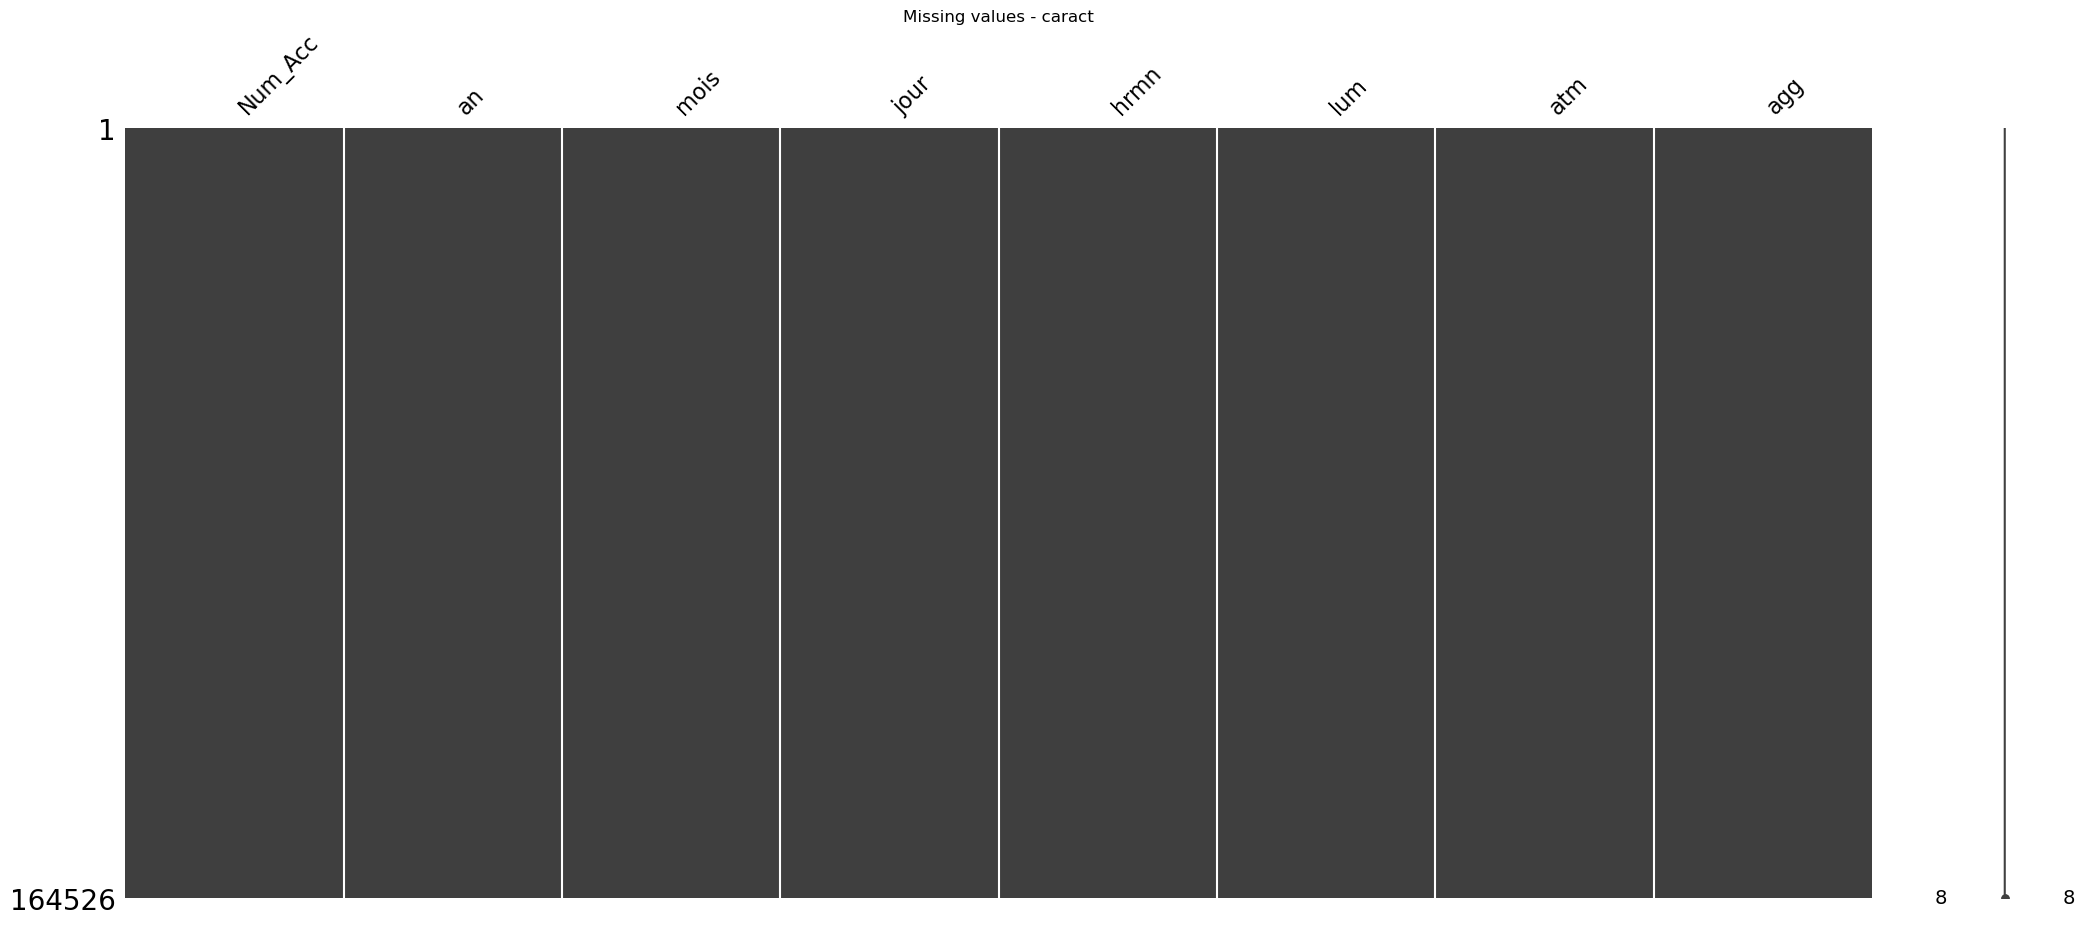


Missing values — lieux


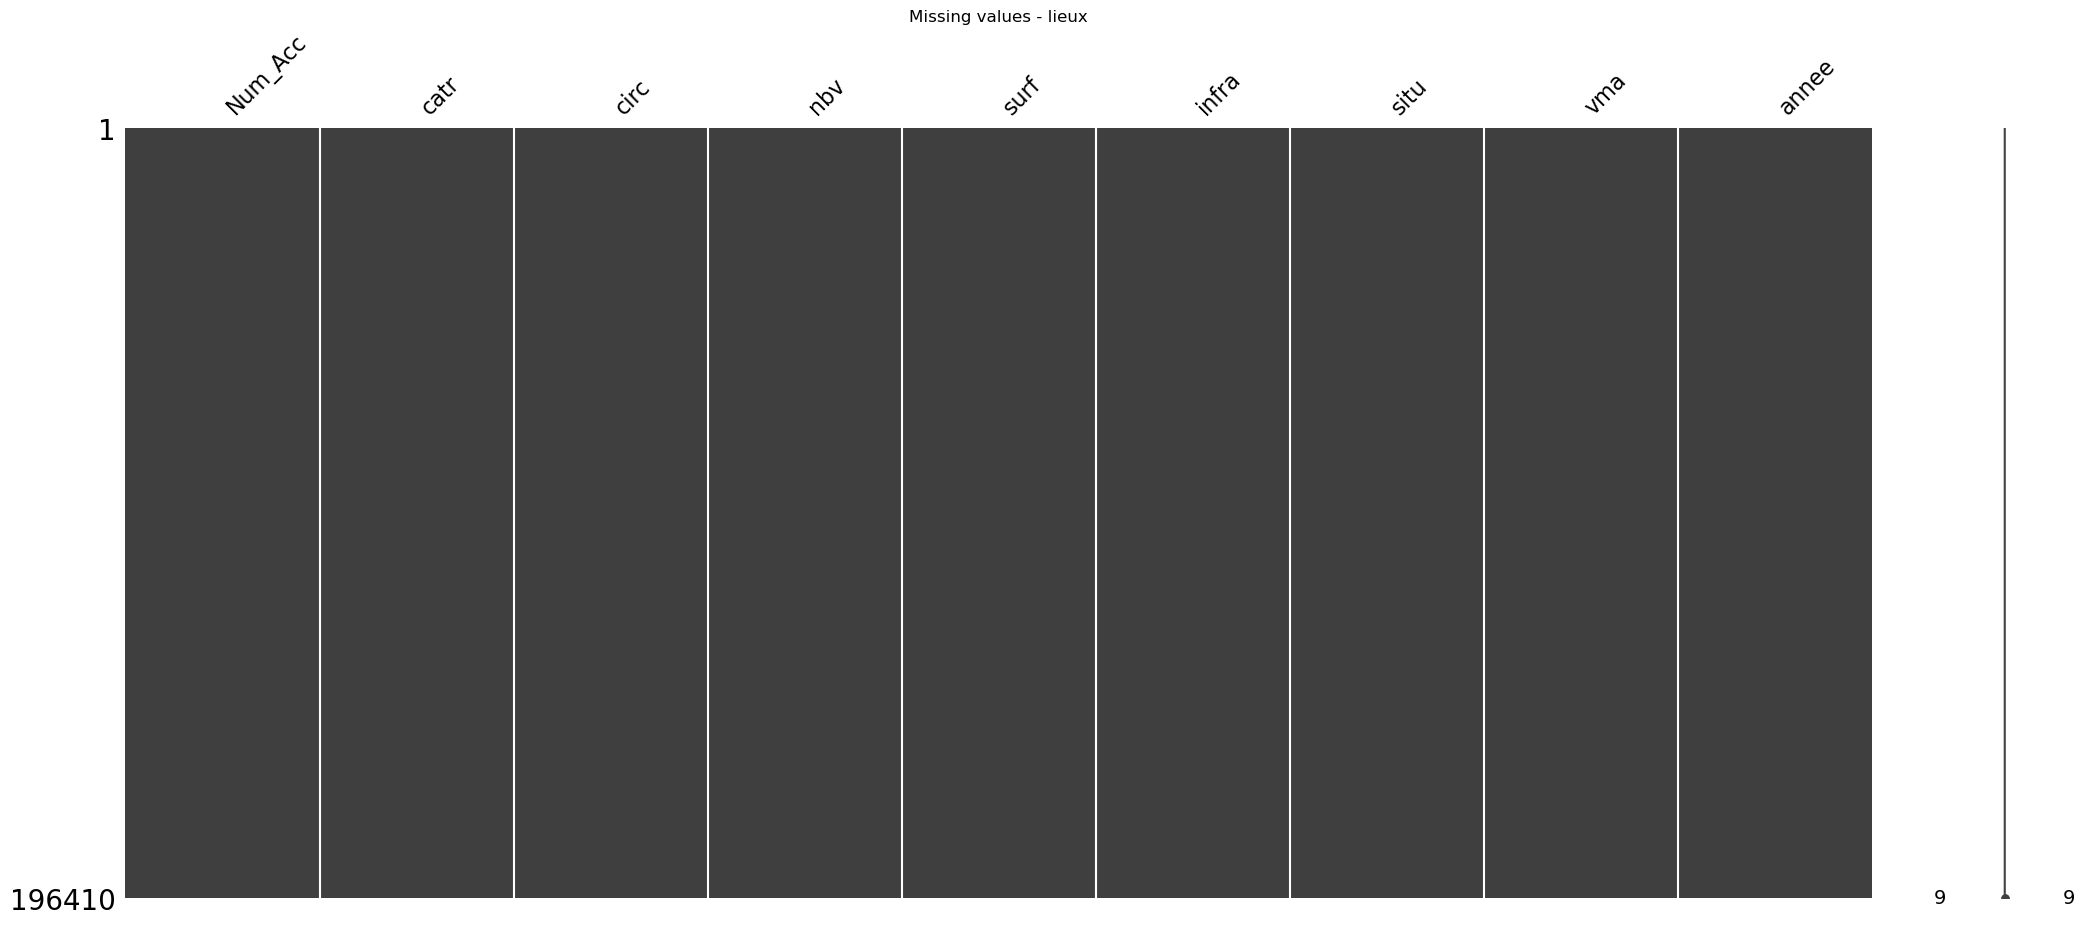


Missing values — cars


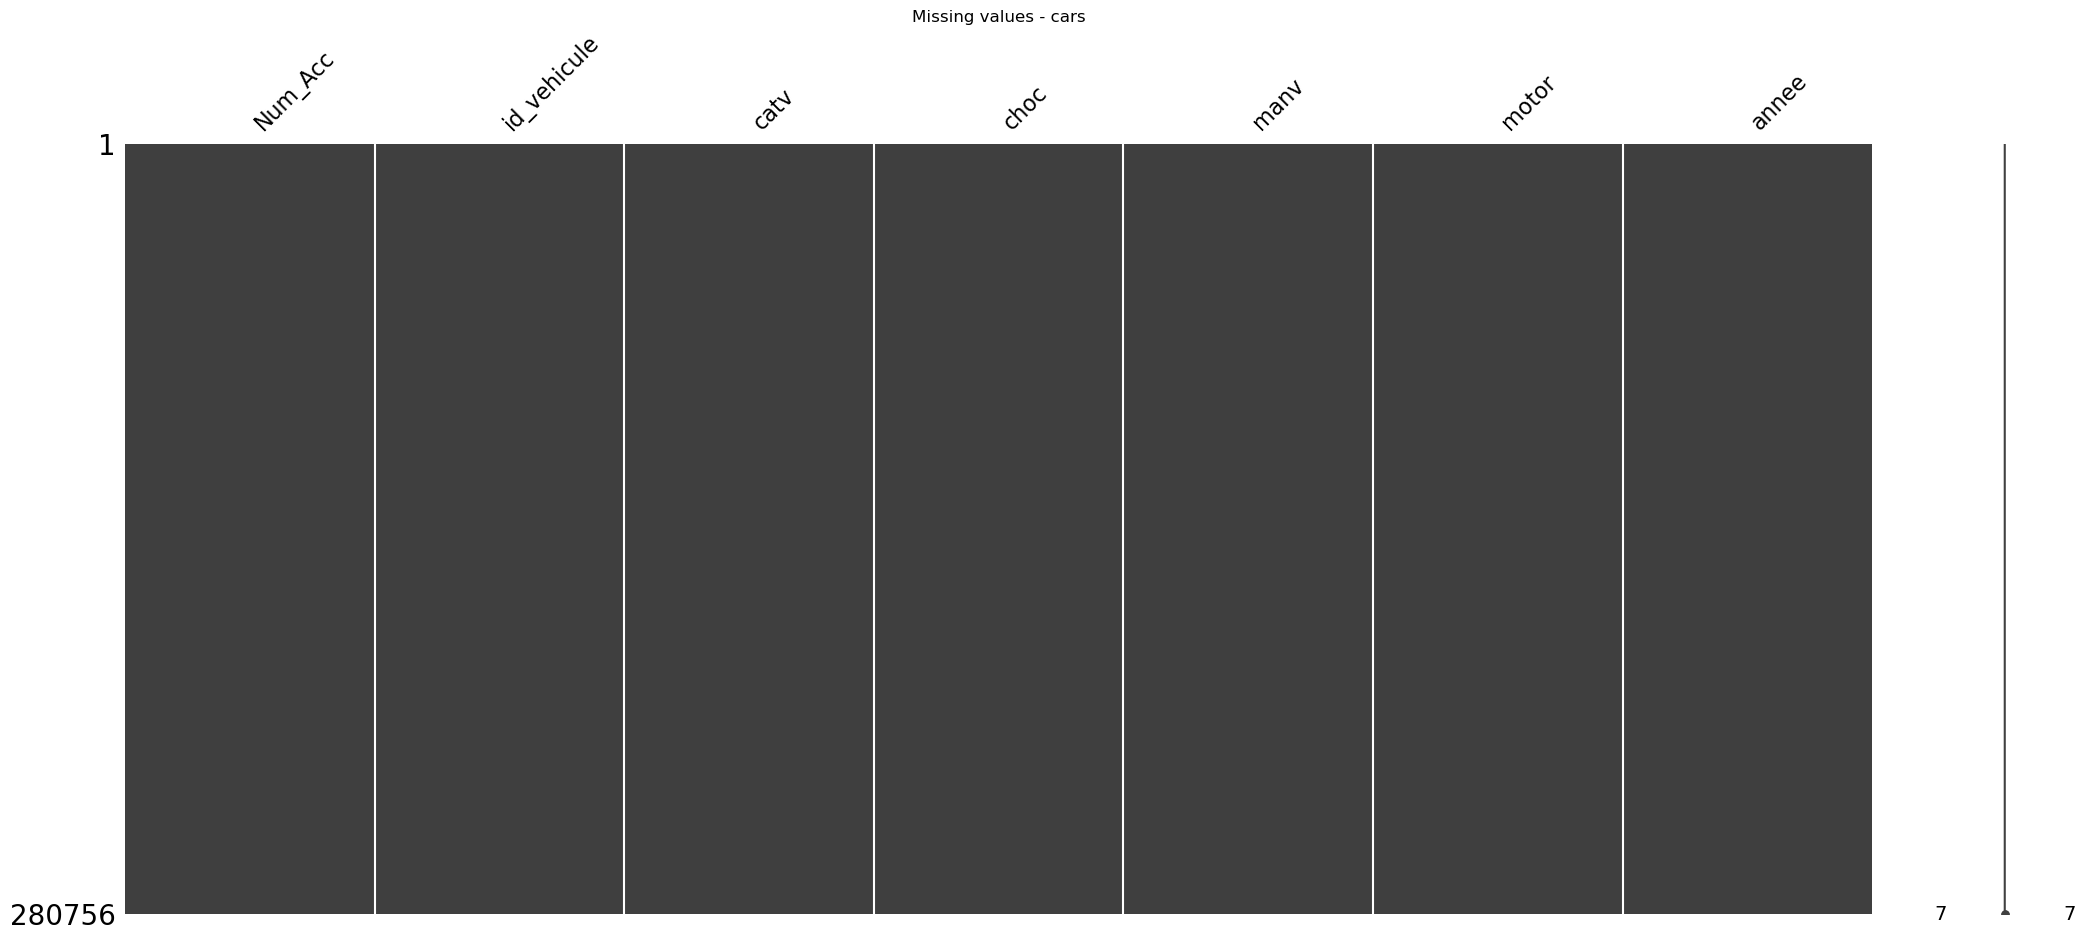


Missing values — usagers


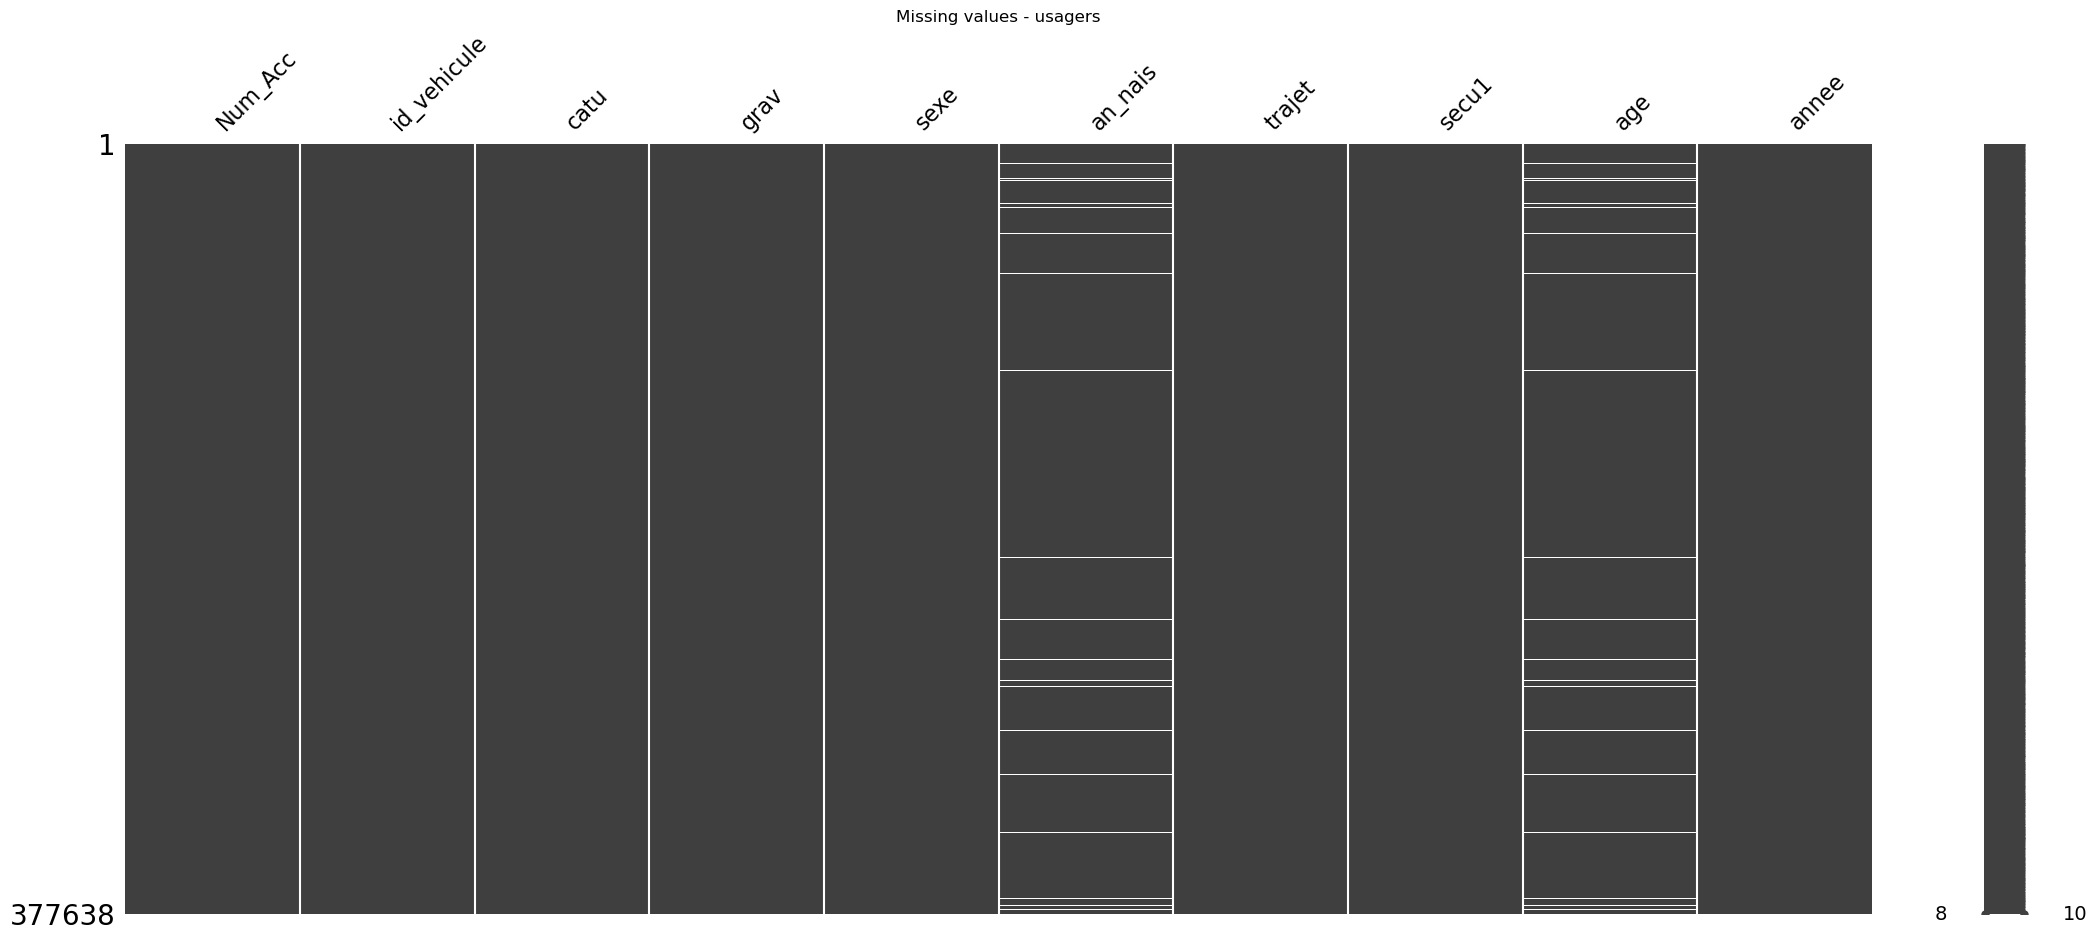

In [329]:
dfs = {
    "caract": df_caract_n,
    "lieux": df_lieux_n,
    "cars": df_cars_n,
    "usagers": df_usagers_n
}

for name, df in dfs.items():
    print(f"\nMissing values — {name}")
    msno.matrix(df)
    plt.title(f"Missing values - {name}")
    plt.show()

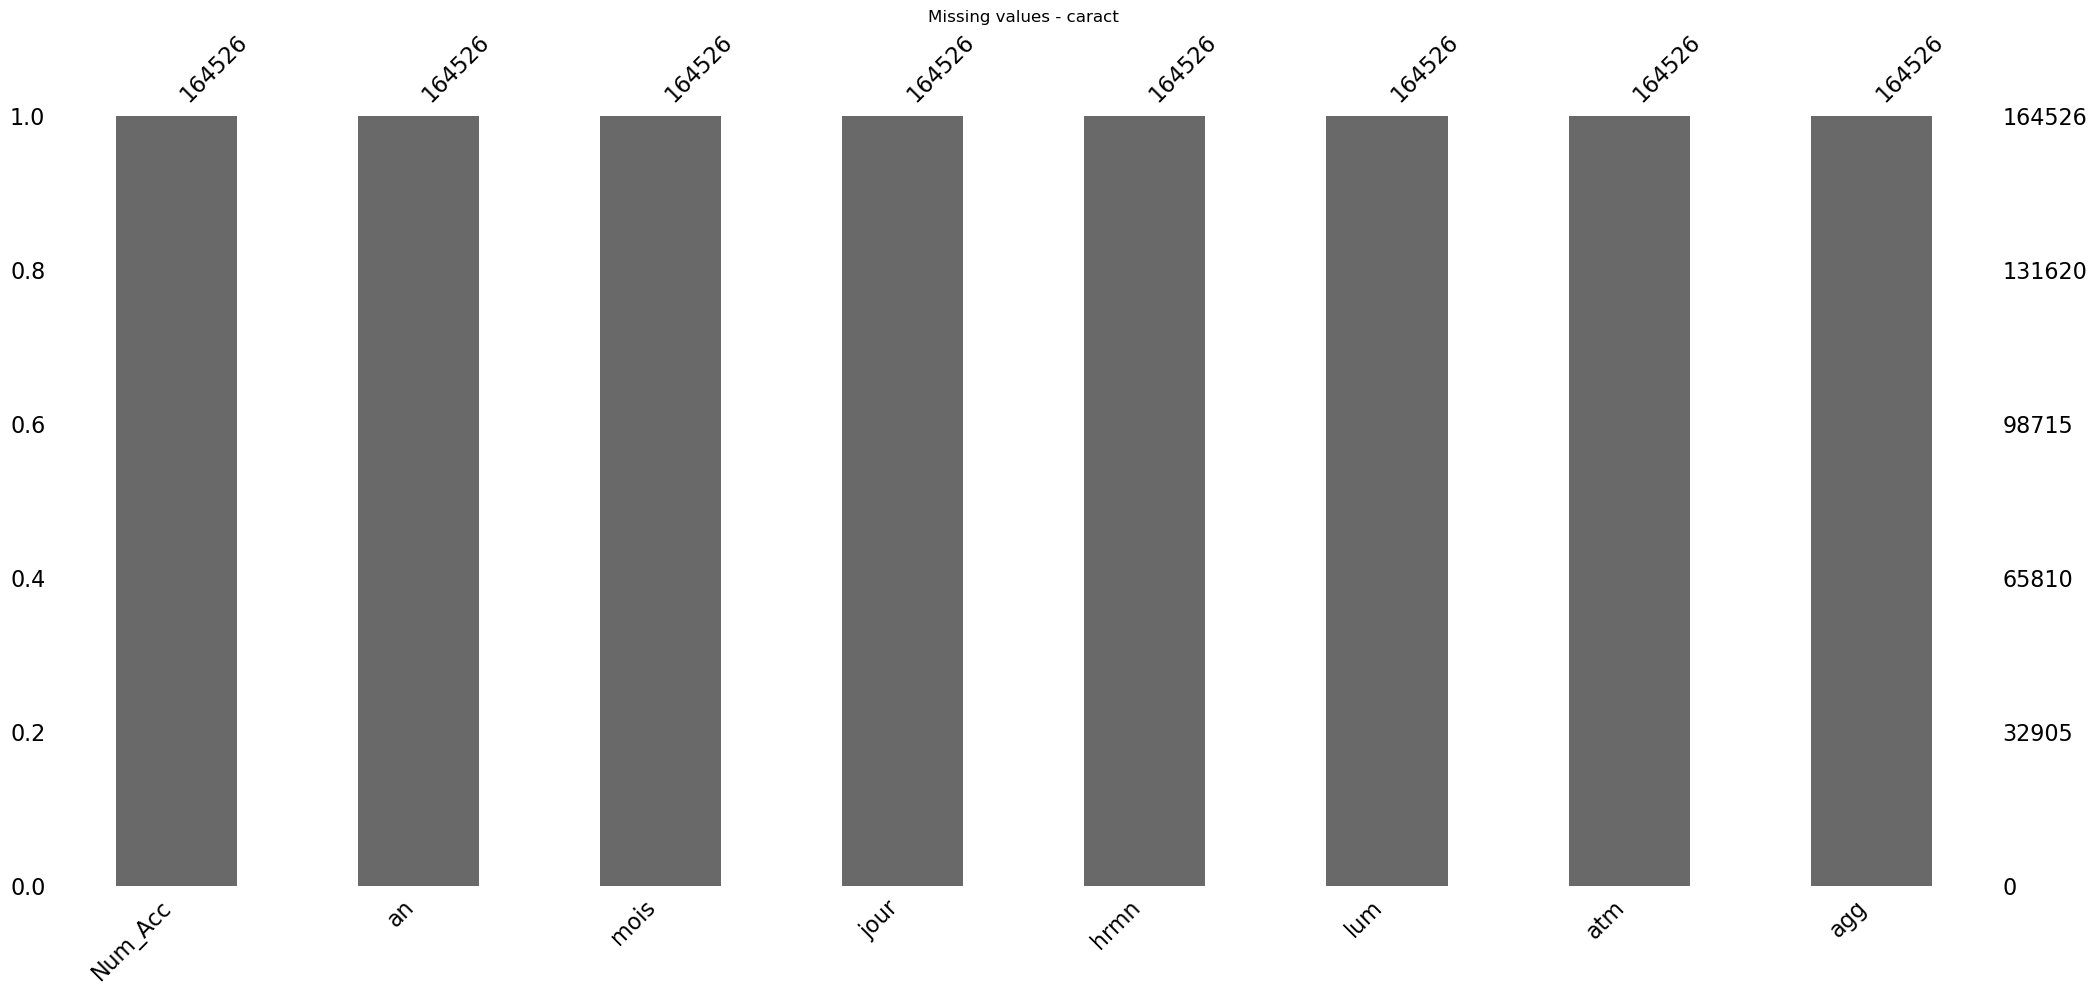

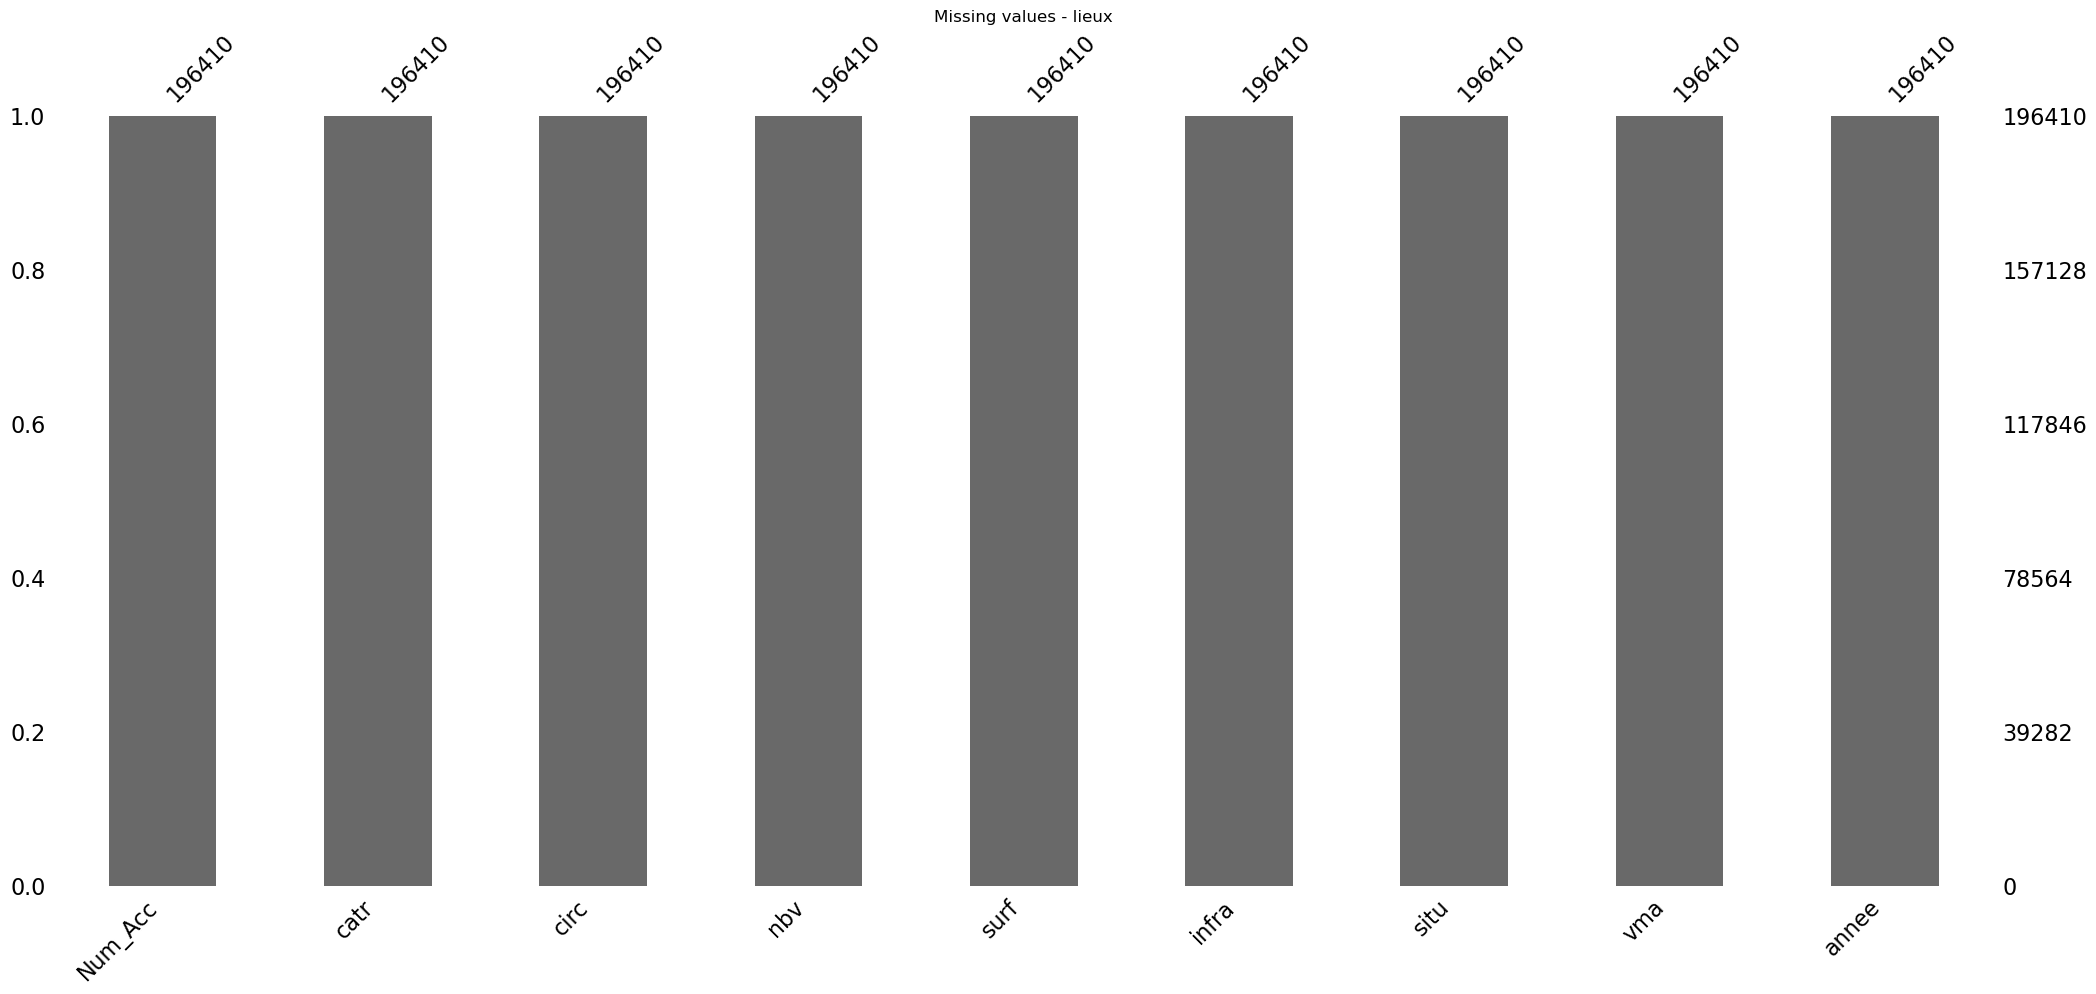

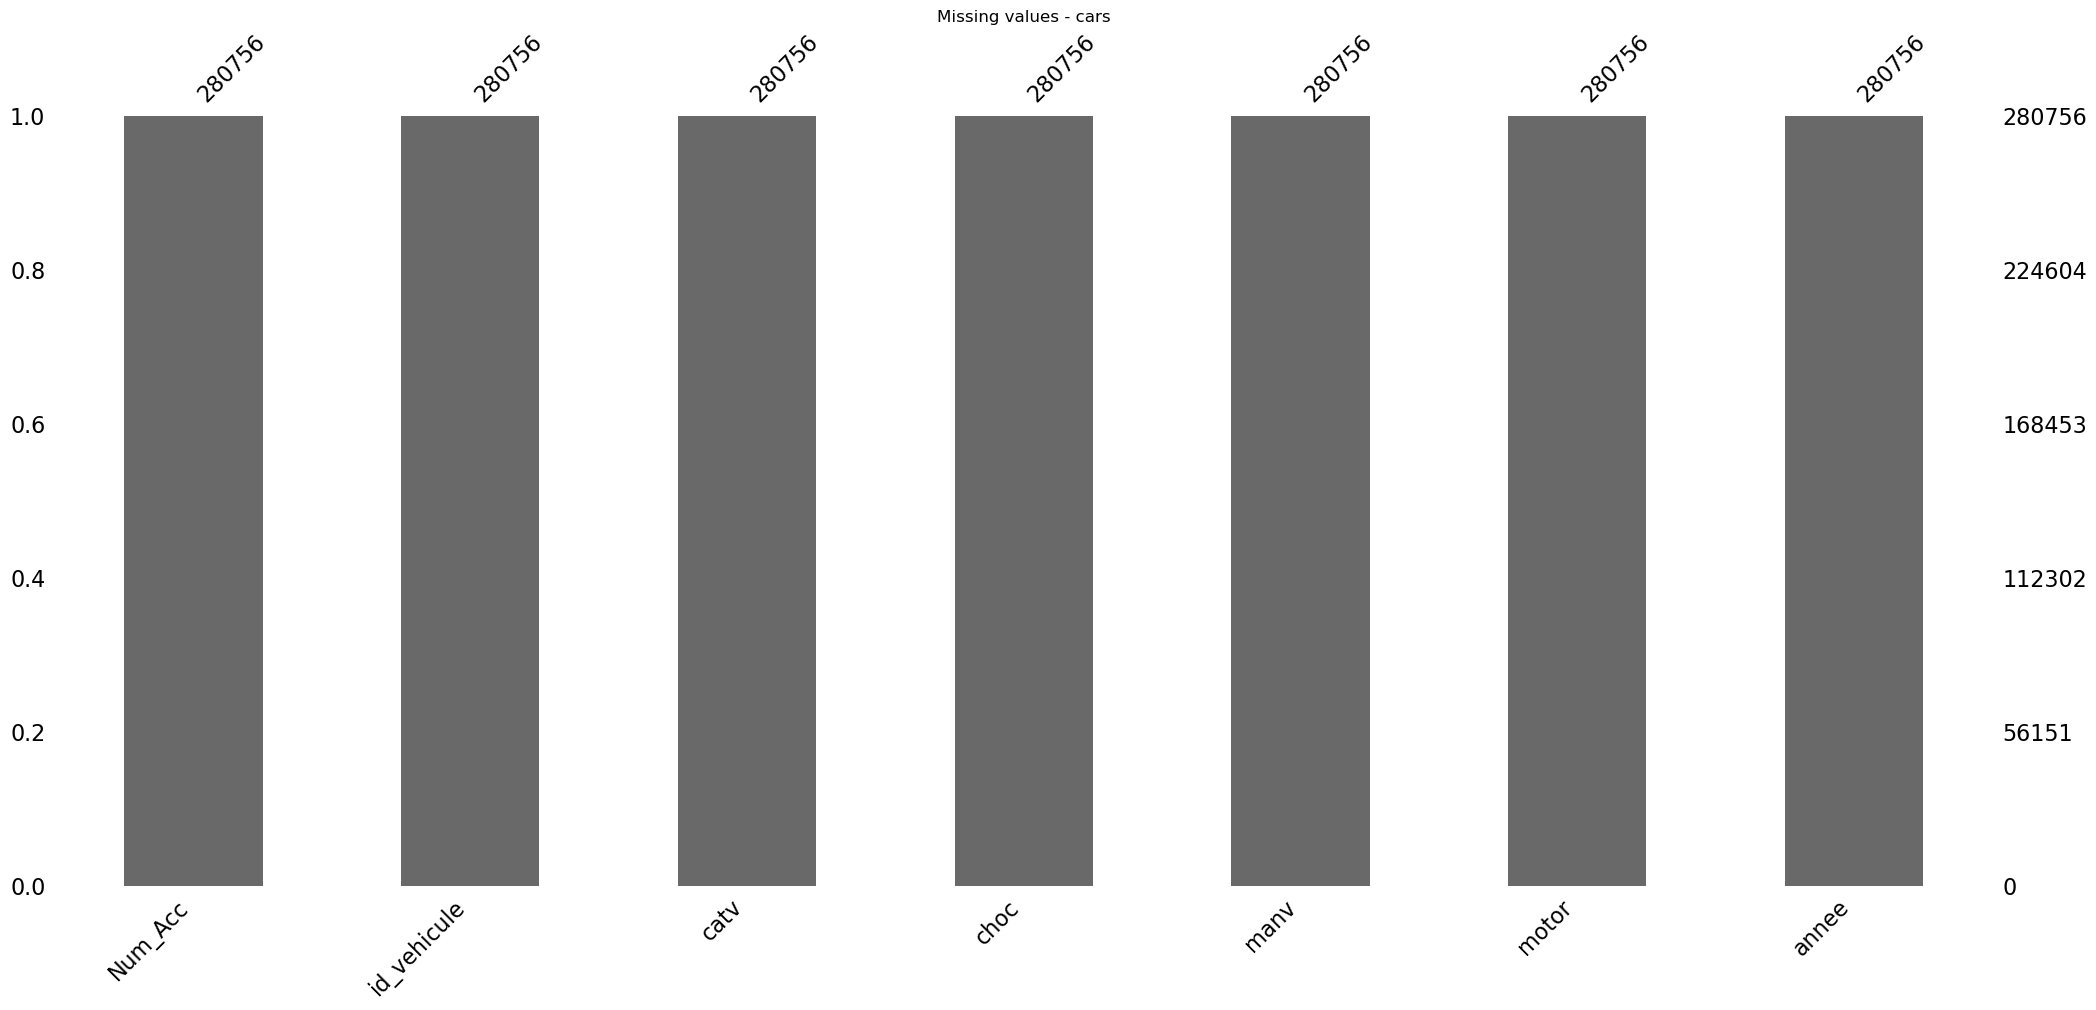

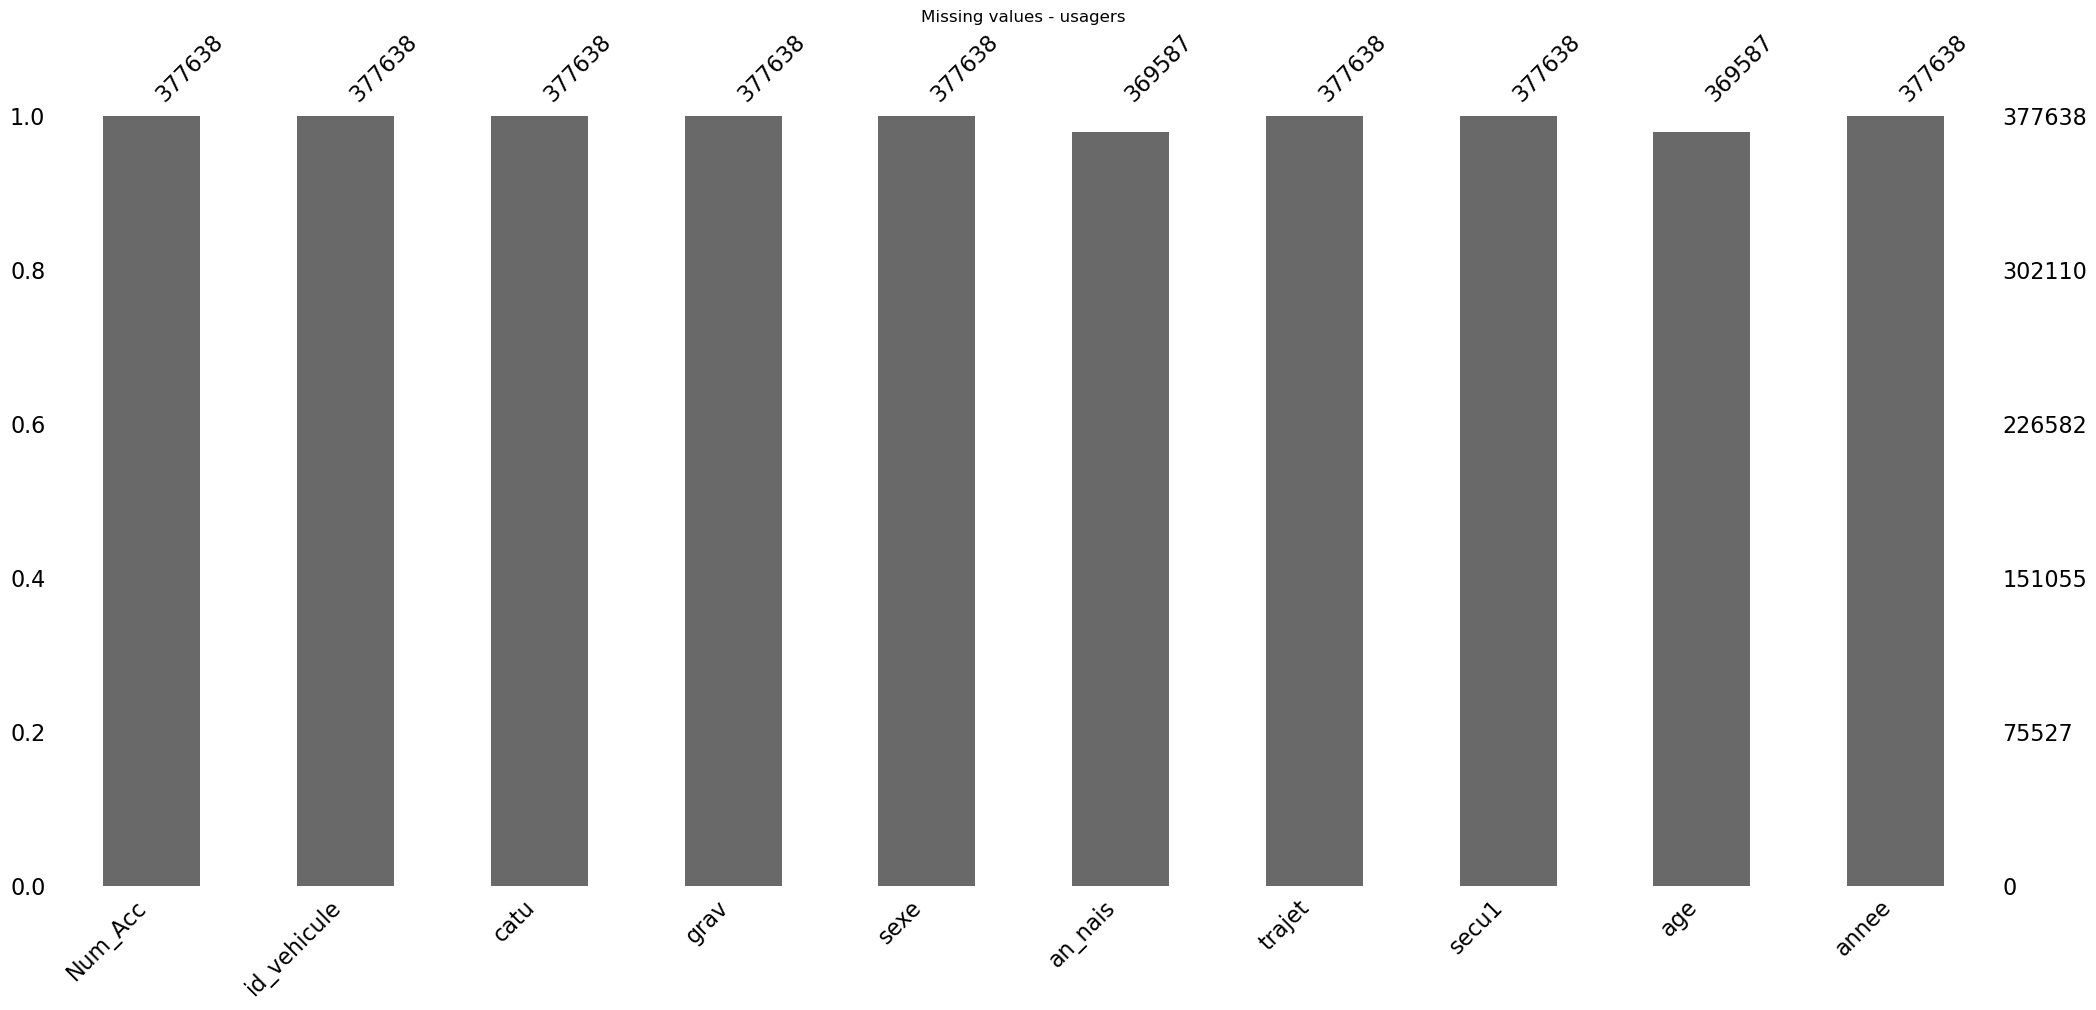

In [330]:
for name, df in dfs.items():
    msno.bar(df)
    plt.title(f"Missing values - {name}")
    plt.show()

<Axes: >

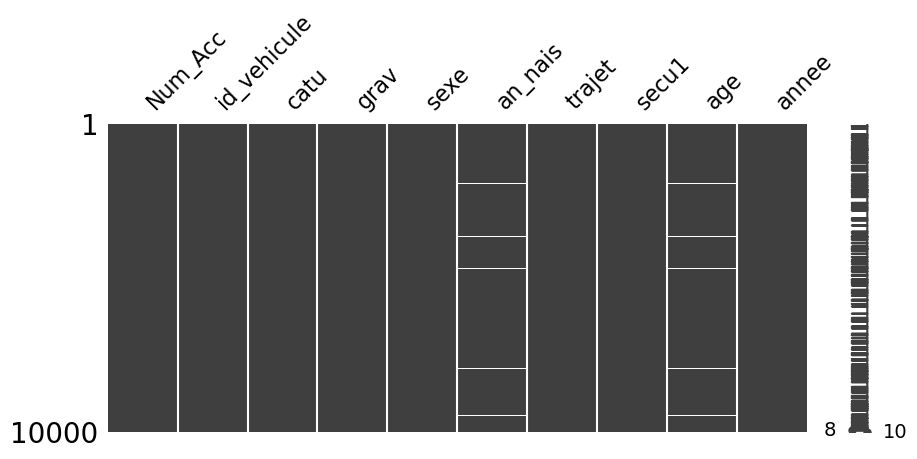

In [331]:
msno.matrix(df.sample(10000), figsize=(10,4))

In [332]:
# Dictionnaire des DataFrames
dfs_n = {
    "caract": df_caract_n,
    "lieux": df_lieux_n,
    "cars": df_cars_n,
    "usagers": df_usagers_n
}

# Boucle pour compter les lignes avec au moins un NaN
for name, df in dfs_n.items():
    n_missing = df.isna().any(axis=1).sum()
    total = df.shape[0]
    print(f"{name}: {n_missing} lignes avec au moins un NaN sur {total} lignes ({n_missing/total*100:.2f}%)")

caract: 0 lignes avec au moins un NaN sur 164526 lignes (0.00%)
lieux: 0 lignes avec au moins un NaN sur 196410 lignes (0.00%)
cars: 0 lignes avec au moins un NaN sur 280756 lignes (0.00%)
usagers: 8051 lignes avec au moins un NaN sur 377638 lignes (2.13%)


Le df_usagers contient des valeurs manquantes au niveau de la colonne "an_nais". Nous allons donc remplacer ces valeurs par la médiane de cette colonne afin de ne perturber l'équilibre des âges de cette colonnes

In [333]:
# Remplacement des valeurs manquantes de df_usagers_n: 
# 1. Calcul de la médiane : 
median_an_nais = df_usagers_n["an_nais"].median()
print("Médiane an_nais :", median_an_nais)

Médiane an_nais : 1988.0


In [334]:
# 2. Remplacer les NaN par la médiane : 
df_usagers_n["an_nais"].fillna(median_an_nais, inplace=True)

C:\Users\Utilisateur\AppData\Local\Temp\ipykernel_10712\2998567893.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_usagers_n["an_nais"].fillna(median_an_nais, inplace=True)


In [335]:
df_usagers_n["an_nais"].isna().sum()  # doit donner 0

0

In [336]:
print("Dimensions df_caract_s :", df_caract_s.shape)
print("Dimensions df_lieux_s  :", df_lieux_s.shape)
print("Dimensions df_usagers_s :", df_usagers_s.shape)
print("Dimensions df_cars_s :", df_cars_s.shape)

Dimensions df_caract_s : (164526, 8)
Dimensions df_lieux_s  : (196410, 9)
Dimensions df_usagers_s : (377638, 10)
Dimensions df_cars_s : (280756, 7)


In [337]:
# Dictionnaire des DataFrames
dfs_n = {
    "caract": df_caract_n,
    "lieux": df_lieux_n,
    "cars": df_cars_n,
    "usagers": df_usagers_n
}

# Boucle pour compter les lignes avec au moins un NaN
for name, df in dfs_n.items():
    n_missing = df.isna().any(axis=1).sum()
    total = df.shape[0]
    print(f"{name}: {n_missing} lignes avec au moins un NaN sur {total} lignes ({n_missing/total*100:.2f}%)")

caract: 0 lignes avec au moins un NaN sur 164526 lignes (0.00%)
lieux: 0 lignes avec au moins un NaN sur 196410 lignes (0.00%)
cars: 0 lignes avec au moins un NaN sur 280756 lignes (0.00%)
usagers: 8051 lignes avec au moins un NaN sur 377638 lignes (2.13%)


# Analyse exploratoire des données et visualisations

In [338]:
df_caract_n.describe(include="all")

,Num_Acc,an,mois,jour,hrmn,lum,atm,agg
count,1.645260e+05,164526.000000,164526.000000,164526.000000,164526,164526.000000,164526.000000,164526.000000
unique,NaN,NaN,NaN,NaN,1440,NaN,NaN,NaN
top,NaN,NaN,NaN,NaN,18:00,NaN,NaN,NaN
freq,NaN,NaN,NaN,NaN,2047,NaN,NaN,NaN
mean,2.022995e+11,2022.994530,6.649539,15.556569,NaN,1.938162,1.633420,1.628302
std,8.165534e+07,0.816555,3.354861,8.721380,NaN,1.487912,1.701532,0.483260
min,2.022000e+11,2022.000000,1.000000,1.000000,NaN,-1.000000,-1.000000,1.000000
25%,2.022000e+11,2022.000000,4.000000,8.000000,NaN,1.000000,1.000000,1.000000
50%,2.023000e+11,2023.000000,7.000000,15.000000,NaN,1.000000,1.000000,2.000000
75%,2.024000e+11,2024.000000,10.000000,23.000000,NaN,3.000000,1.000000,2.000000


Points clés :

- Décrit le contexte temporel et environnemental des accidents (jour, année, luminosité, météo).

- Accidents répartis de façon équilibrée entre 2022 et 2024.

La majorité des accidents surviennent :

- en pleine journée

- par temps normal.

La variable heure est entièrement manquante, empêchant l’analyse par tranches horaires.

Présence de valeurs -1 indiquant des données non renseignées.

Enjeu prévention :
Les accidents ne sont pas uniquement liés à des conditions difficiles, mais se produisent souvent dans des conditions normales, suggérant un rôle majeur du comportement des usagers.

In [339]:
df_lieux_n.describe(include="all")

,Num_Acc,catr,circ,nbv,surf,infra,situ,vma,annee
count,1.964100e+05,196410.000000,196410.000000,196410,196410.000000,196410.000000,196410.000000,196410.000000,196410.000000
unique,NaN,NaN,NaN,30,NaN,NaN,NaN,NaN,NaN
top,NaN,NaN,NaN,2,NaN,NaN,NaN,NaN,NaN
freq,NaN,NaN,NaN,105584,NaN,NaN,NaN,NaN,NaN
mean,2.023076e+11,3.389578,1.747584,NaN,1.262441,0.815427,1.628950,54.855674,2023.076096
std,7.958855e+07,1.156117,0.919564,NaN,0.804881,2.175524,1.635727,26.294458,0.795887
min,2.022000e+11,1.000000,-1.000000,NaN,-1.000000,-1.000000,-1.000000,-1.000000,2022.000000
25%,2.022000e+11,3.000000,1.000000,NaN,1.000000,0.000000,1.000000,50.000000,2022.000000
50%,2.023000e+11,3.000000,2.000000,NaN,1.000000,0.000000,1.000000,50.000000,2023.000000
75%,2.024000e+11,4.000000,2.000000,NaN,1.000000,0.000000,1.000000,70.000000,2024.000000


Points clés :

- Décrit les caractéristiques de la route (type de voie, vitesse autorisée, état de la chaussée).

- Forte concentration des accidents en zone urbaine.

- La vitesse autorisée la plus fréquente est 50 km/h.

- La majorité des accidents ont lieu sur une chaussée normale.

Présence de valeurs aberrantes (vitesse négative ou irréaliste)=> à traiter 

Enjeu prévention :
La gestion de la vitesse et la sécurité en milieu urbain sont des leviers essentiels pour réduire les accidents.

In [340]:
df_usagers_n.describe(include="all")

,Num_Acc,id_vehicule,catu,grav,sexe,an_nais,trajet,secu1,age,annee
count,3.776380e+05,377638,377638.000000,377638.000000,377638.000000,377638.000000,377638.000000,377638.000000,369587.000000,377638.000000
unique,NaN,280692,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,155 602 779,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,65,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,2.022996e+11,NaN,1.332758,2.516942,1.270778,1984.330706,3.124355,1.906045,38.746033,2022.996094
std,8.166330e+07,NaN,0.610660,1.378004,0.563677,18.952878,2.766093,2.347074,19.139187,0.816635
min,2.022000e+11,NaN,1.000000,-1.000000,-1.000000,1913.000000,-1.000000,-1.000000,0.000000,2022.000000
25%,2.022000e+11,NaN,1.000000,1.000000,1.000000,1971.000000,0.000000,1.000000,23.000000,2022.000000
50%,2.023000e+11,NaN,1.000000,3.000000,1.000000,1988.000000,4.000000,1.000000,35.000000,2023.000000
75%,2.024000e+11,NaN,2.000000,4.000000,2.000000,2000.000000,5.000000,2.000000,52.000000,2024.000000


Points clés :

- Contient les informations sur les personnes impliquées dans les accidents.

- Les hommes sont plus impliqués que les femmes.

- Les accidents concernent principalement des adultes en âge actif.

- Les conducteurs représentent la majorité des usagers impliqués.

- La gravité des accidents est majoritairement non mortelle, mais reste significative.

- Données incomplètes sur les équipements de sécurité.

Enjeu prévention :
Les facteurs humains (âge, sexe, comportements, protection) sont déterminants dans la gravité des accidents.

In [341]:
df_cars_n.describe(include="all")

,Num_Acc,id_vehicule,catv,choc,manv,motor,annee
count,2.807560e+05,280756,280756.000000,280756.000000,280756.000000,280756.000000,280756.000000
unique,NaN,280756,NaN,NaN,NaN,NaN,NaN
top,NaN,813 952,NaN,NaN,NaN,NaN,NaN
freq,NaN,1,NaN,NaN,NaN,NaN,NaN
mean,2.022994e+11,NaN,13.639473,2.874770,6.848741,1.331612,2022.993535
std,8.164713e+07,NaN,14.533111,2.417073,7.864581,1.106465,0.816473
min,2.022000e+11,NaN,-1.000000,-1.000000,-1.000000,-1.000000,2022.000000
25%,2.022000e+11,NaN,7.000000,1.000000,1.000000,1.000000,2022.000000
50%,2.023000e+11,NaN,7.000000,2.000000,2.000000,1.000000,2023.000000
75%,2.024000e+11,NaN,10.000000,4.000000,14.000000,1.000000,2024.000000


# Synthèse globale : 

Les accidents se produisent majoritairement dans des conditions normales.

Les zones urbaines à 50 km/h sont les plus accidentogènes.

Les conducteurs masculins adultes sont les plus concernés.

La qualité des données impose un nettoyage rigoureux avant analyse finale.

### Visualisations : 

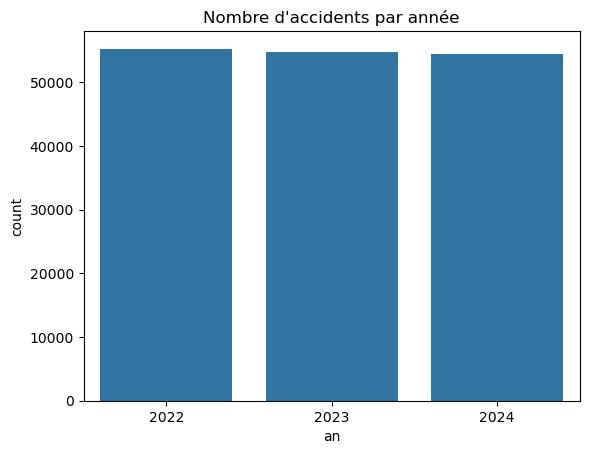

In [342]:
# Accidents par année
sns.countplot(x="an", data=df_caract_n)
plt.title("Nombre d'accidents par année")
plt.show()

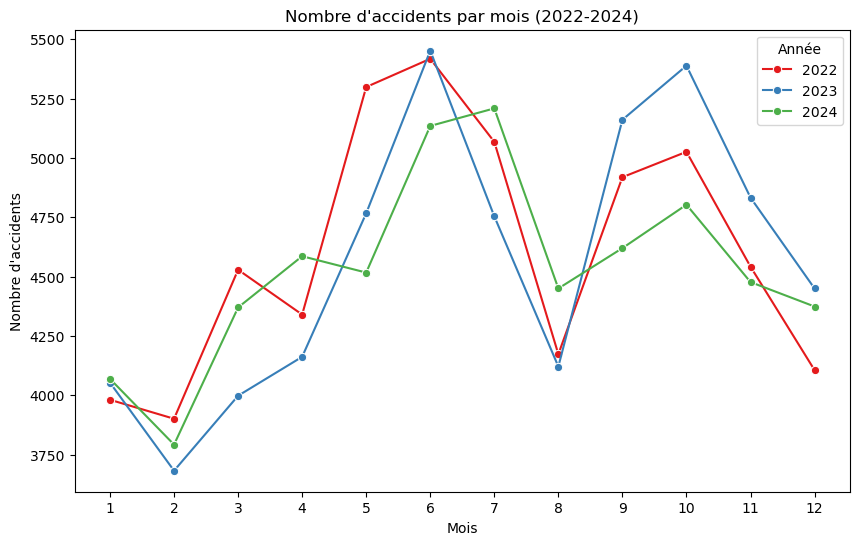

In [343]:
# Créer un DataFrame agrégé : nombre d'accidents par mois et année
df_month = df_caract_n.groupby(["an", "mois"]).size().reset_index(name="nb_accidents")

# Plot
plt.figure(figsize=(10,6))
sns.lineplot(data=df_month, x="mois", y="nb_accidents", hue="an", palette="Set1", marker="o")
plt.title("Nombre d'accidents par mois (2022-2024)")
plt.xlabel("Mois")
plt.ylabel("Nombre d'accidents")
plt.xticks(range(1,13))
plt.legend(title="Année")
plt.show()


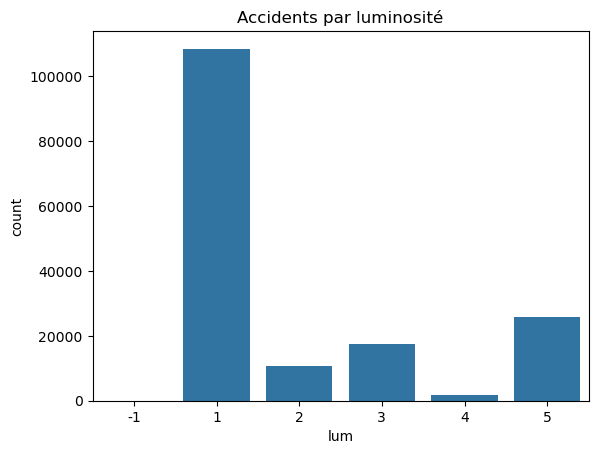

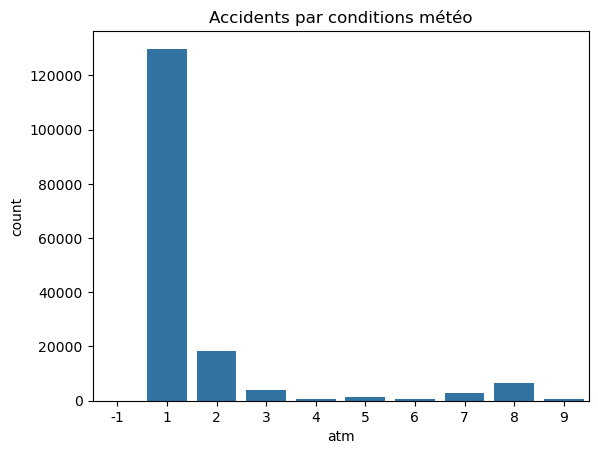

In [344]:
sns.countplot(x="lum", data=df_caract_n)
plt.title("Accidents par luminosité")
plt.show()

sns.countplot(x="atm", data=df_caract_n)
plt.title("Accidents par conditions météo")
plt.show()

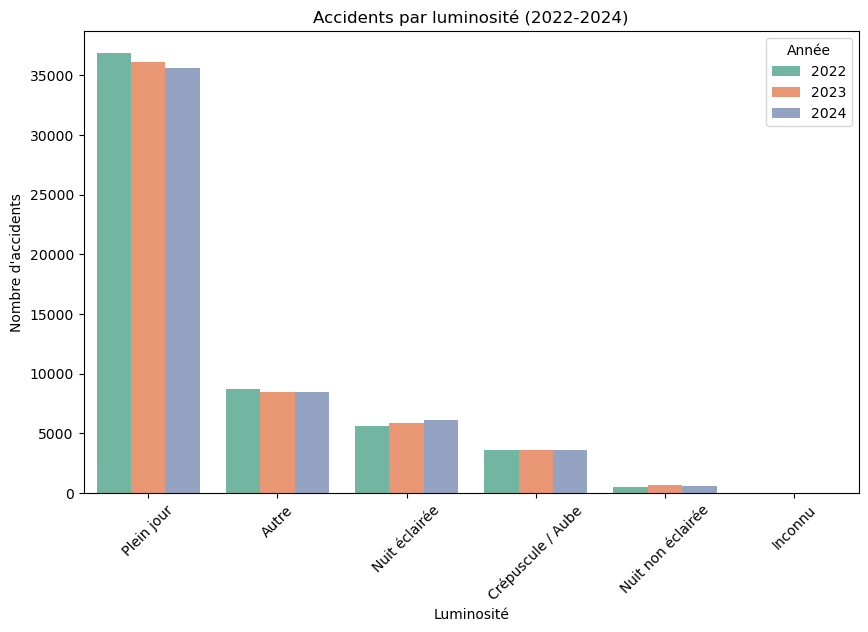

In [346]:
lum_map = {
    -1: "Inconnu",
    1: "Plein jour",
    2: "Crépuscule / Aube",
    3: "Nuit éclairée",
    4: "Nuit non éclairée",
    5: "Autre"
}

df_caract_n["lum_desc"] = df_caract_n["lum"].map(lum_map)

# Plot par année
plt.figure(figsize=(10,6))
sns.countplot(data=df_caract_n, x="lum_desc", hue="an", palette="Set2")
plt.title("Accidents par luminosité (2022-2024)")
plt.xlabel("Luminosité")
plt.ylabel("Nombre d'accidents")
plt.xticks(rotation=45)
plt.legend(title="Année")
plt.show()

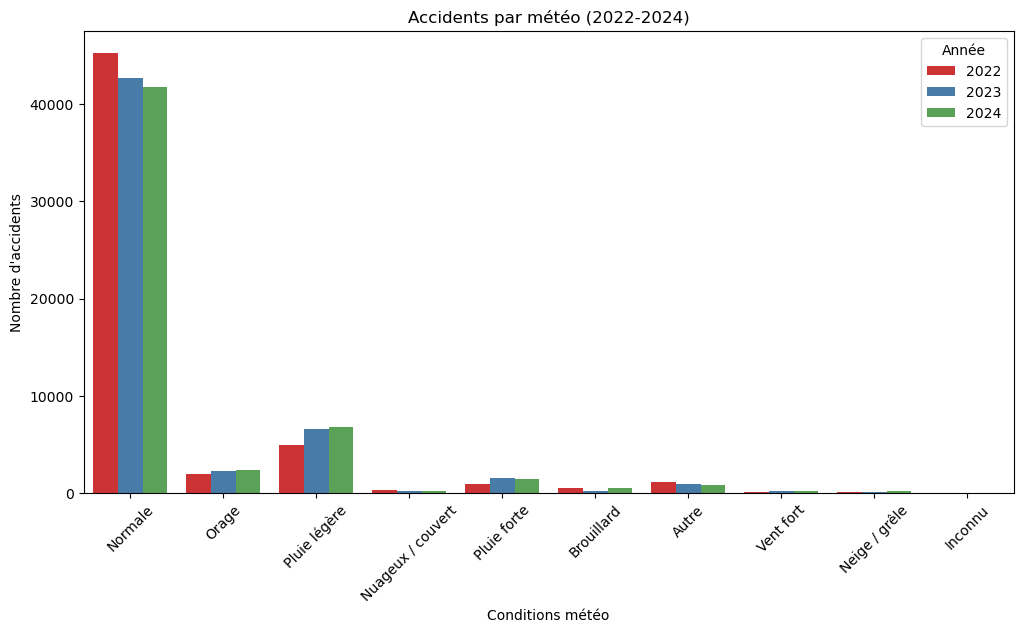

In [347]:
atm_map = {
    -1: "Inconnu",
    1: "Normale",
    2: "Pluie légère",
    3: "Pluie forte",
    4: "Neige / grêle",
    5: "Brouillard",
    6: "Vent fort",
    7: "Autre",
    8: "Orage",
    9: "Nuageux / couvert"
}

df_caract_n["atm_desc"] = df_caract_n["atm"].map(atm_map)

plt.figure(figsize=(12,6))
sns.countplot(data=df_caract_n, x="atm_desc", hue="an", palette="Set1")
plt.title("Accidents par météo (2022-2024)")
plt.xlabel("Conditions météo")
plt.ylabel("Nombre d'accidents")
plt.xticks(rotation=45)
plt.legend(title="Année")
plt.show()

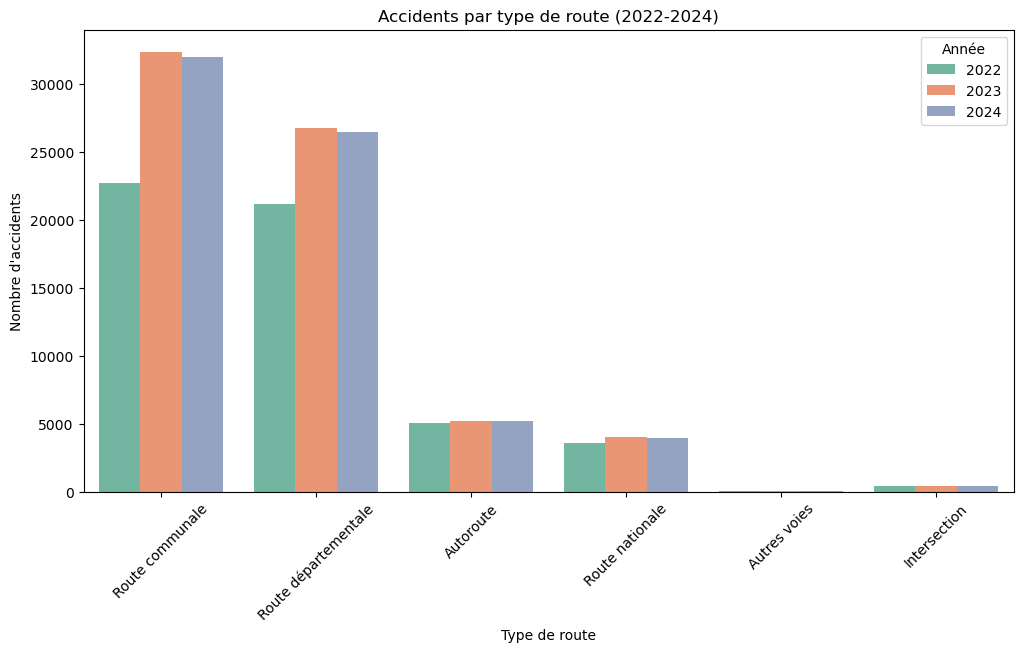

In [348]:
catr_map = {
    1: "Autoroute",
    2: "Route nationale",
    3: "Route départementale",
    4: "Route communale",
    5: "Autres voies",
    6: "Intersection"
}

df_lieux_n["catr_desc"] = df_lieux_n["catr"].map(catr_map)

plt.figure(figsize=(12,6))
sns.countplot(data=df_lieux_n, x="catr_desc", hue="annee", palette="Set2")
plt.title("Accidents par type de route (2022-2024)")
plt.xlabel("Type de route")
plt.ylabel("Nombre d'accidents")
plt.xticks(rotation=45)
plt.legend(title="Année")
plt.show()


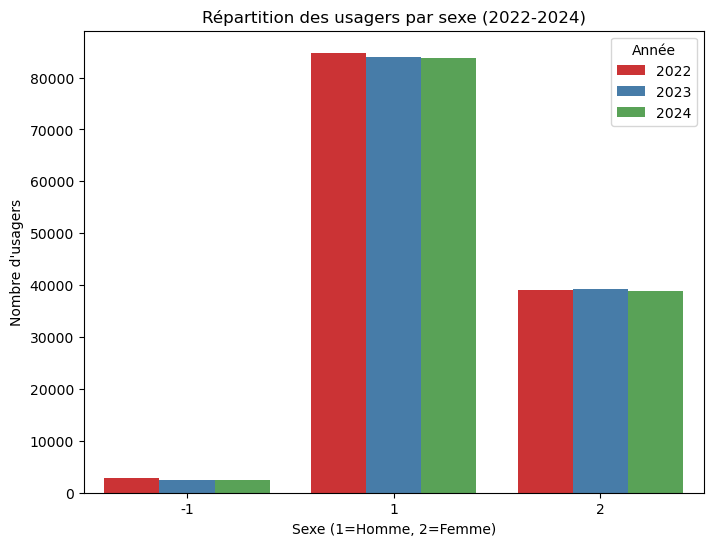

In [349]:
plt.figure(figsize=(8,6))
sns.countplot(data=df_usagers_n, x="sexe", hue="annee", palette="Set1")
plt.title("Répartition des usagers par sexe (2022-2024)")
plt.xlabel("Sexe (1=Homme, 2=Femme)")
plt.ylabel("Nombre d'usagers")
plt.legend(title="Année")
plt.show()

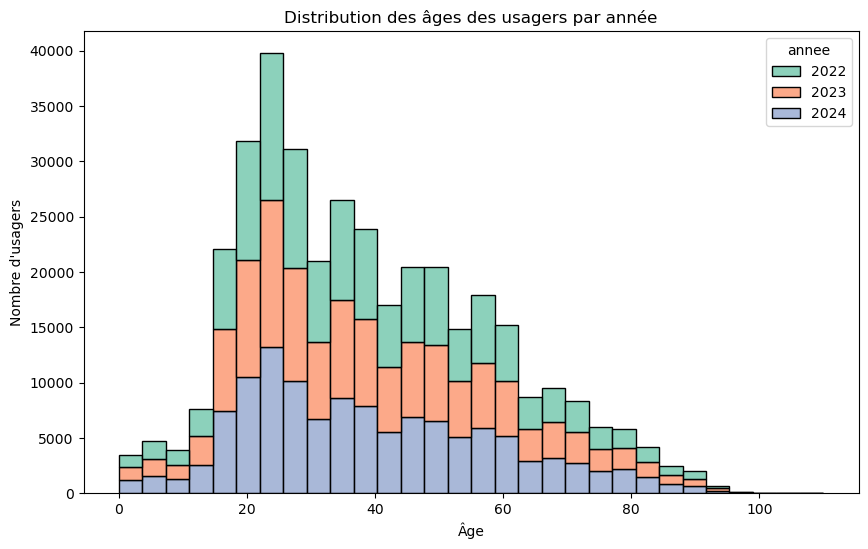

In [350]:
plt.figure(figsize=(10,6))
sns.histplot(data=df_usagers_n, x="age", bins=30, hue="annee", multiple="stack", palette="Set2")
plt.title("Distribution des âges des usagers par année")
plt.xlabel("Âge")
plt.ylabel("Nombre d'usagers")
plt.show()

C:\Users\Utilisateur\AppData\Local\Temp\ipykernel_10712\2839031150.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_usagers_n, x="grav", y="age", palette="Set3")


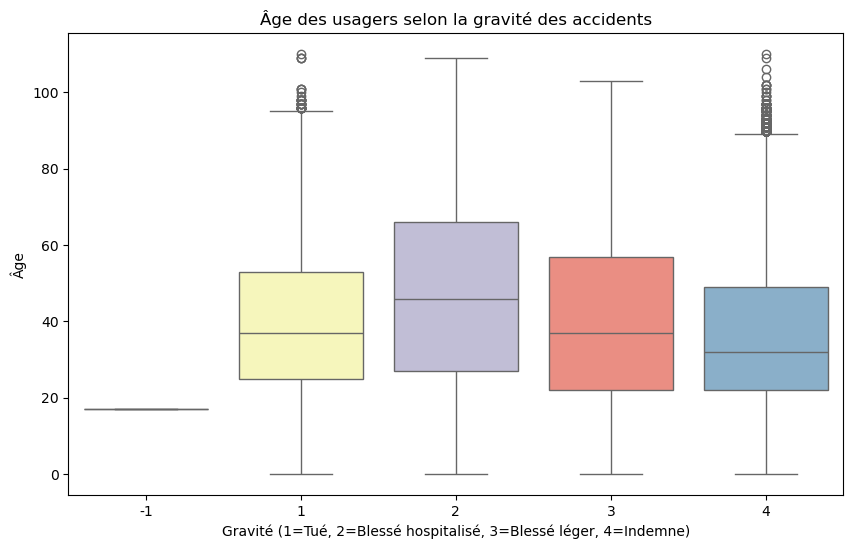

In [351]:
plt.figure(figsize=(10,6))
sns.boxplot(data=df_usagers_n, x="grav", y="age", palette="Set3")
plt.title("Âge des usagers selon la gravité des accidents")
plt.xlabel("Gravité (1=Tué, 2=Blessé hospitalisé, 3=Blessé léger, 4=Indemne)")
plt.ylabel("Âge")
plt.show()

In [353]:
df_merge_n = df_usagers_n.merge(df_cars_n, on=["Num_Acc", "id_vehicule"], how="left") \
                         .merge(df_caract_n[["Num_Acc", "lum"]], on="Num_Acc", how="left")

# Mapping luminosité
lum_map = {
    -1: "Inconnu",
    1: "Jour",
    2: "Crépuscule/Aube",
    3: "Nuit éclairée",
    4: "Nuit non éclairée",
    5: "Autre"
}
df_merge_n["lum_desc"] = df_merge_n["lum"].map(lum_map)

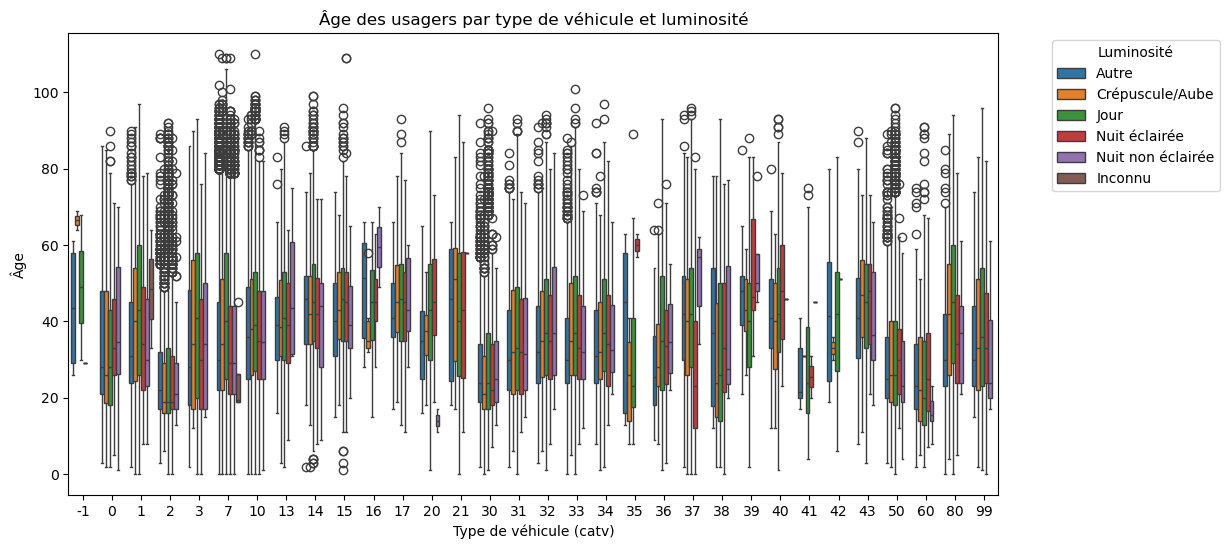

In [354]:
plt.figure(figsize=(12,6))
sns.boxplot(data=df_merge_n, x="catv", y="age", hue="lum_desc")
plt.title("Âge des usagers par type de véhicule et luminosité")
plt.xlabel("Type de véhicule (catv)")
plt.ylabel("Âge")
plt.legend(title="Luminosité", bbox_to_anchor=(1.05,1), loc="upper left")
plt.show()

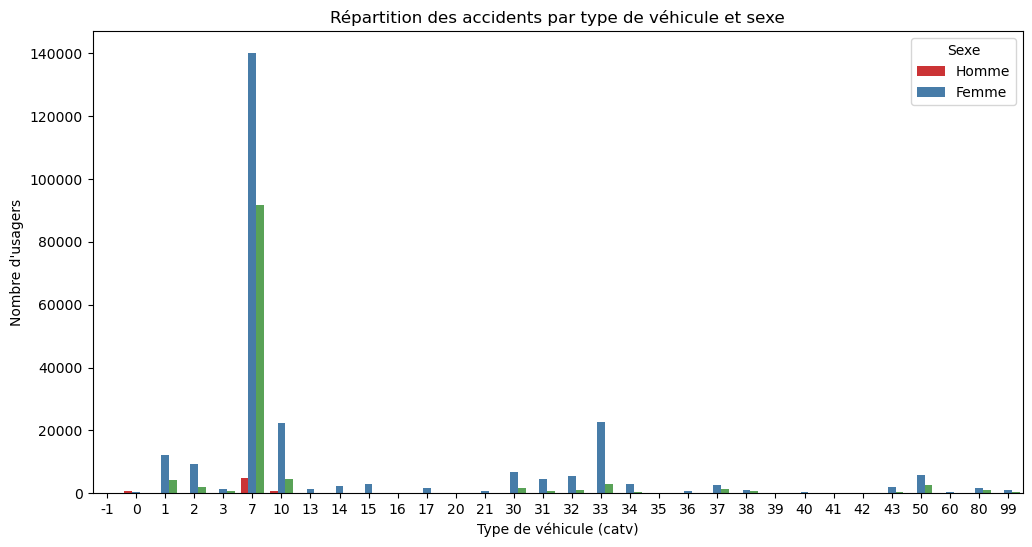

In [355]:
plt.figure(figsize=(12,6))
sns.countplot(data=df_merge_n, x="catv", hue="sexe", palette="Set1")
plt.title("Répartition des accidents par type de véhicule et sexe")
plt.xlabel("Type de véhicule (catv)")
plt.ylabel("Nombre d'usagers")
plt.legend(title="Sexe", labels=["Homme", "Femme"])
plt.show()

In [356]:
catv_map = {
    1: "Véhicule particulier",
    2: "Taxi / Transport",
    3: "Bus",
    4: "PL < 3,5t",
    5: "PL ≥ 3,5t",
    6: "Tracteur agricole",
    7: "Moto",
    8: "Cyclomoteur",
    9: "Vélo",
    10: "Autre",
    11: "Inconnu"
}

df_merge_n["catv_desc"] = df_merge_n["catv"].map(catv_map)

C:\Users\Utilisateur\AppData\Local\Temp\ipykernel_10712\3588117264.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_merge_n, x="catv_desc", order=df_merge_n["catv_desc"].value_counts().index, palette="Set3")


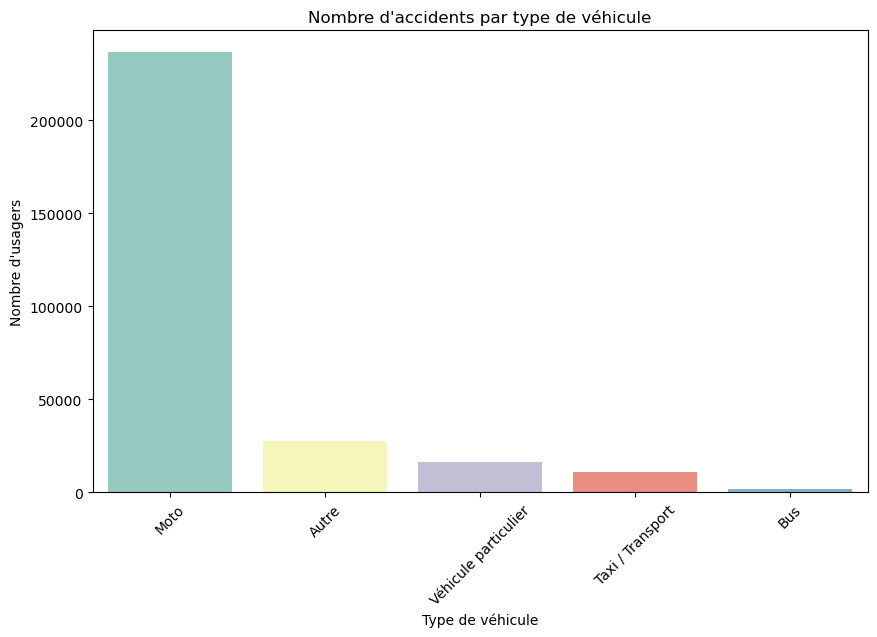

In [358]:
plt.figure(figsize=(10,6))
sns.countplot(data=df_merge_n, x="catv_desc", order=df_merge_n["catv_desc"].value_counts().index, palette="Set3")
plt.title("Nombre d'accidents par type de véhicule")
plt.xlabel("Type de véhicule")
plt.ylabel("Nombre d'usagers")
plt.xticks(rotation=45)
plt.show()

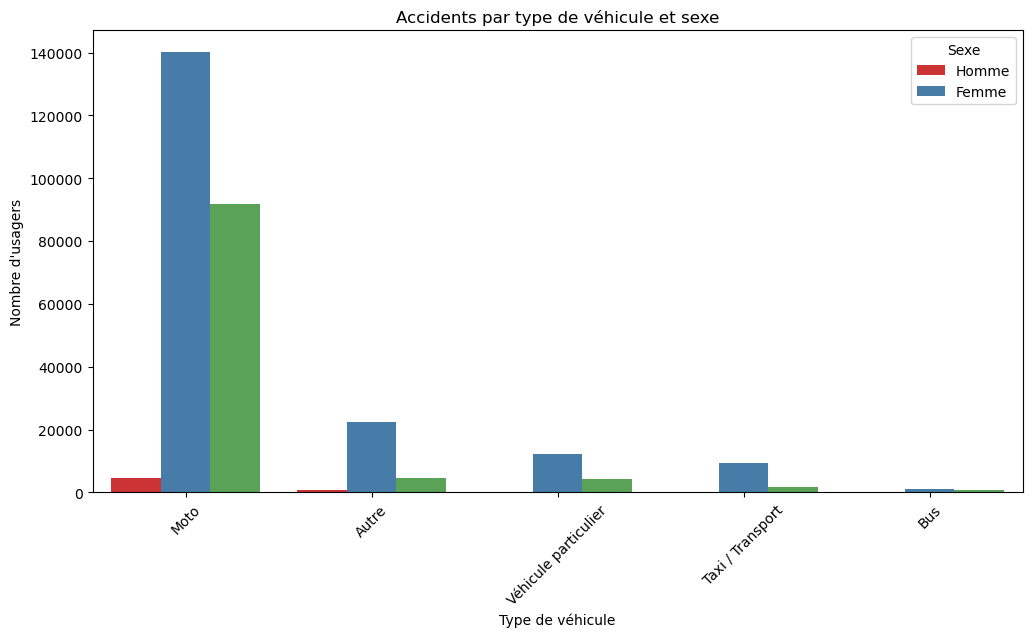

In [359]:
plt.figure(figsize=(12,6))
sns.countplot(data=df_merge_n, x="catv_desc", hue="sexe", palette="Set1", order=df_merge_n["catv_desc"].value_counts().index)
plt.title("Accidents par type de véhicule et sexe")
plt.xlabel("Type de véhicule")
plt.ylabel("Nombre d'usagers")
plt.legend(title="Sexe", labels=["Homme","Femme"])
plt.xticks(rotation=45)
plt.show()

In [362]:
grav_map = {
    1: "Tué",
    2: "Blessé hospitalisé",
    3: "Blessé léger",
    4: "Indemne"
}

df_merge_n["grav_desc"] = df_merge_n["grav"].map(grav_map)

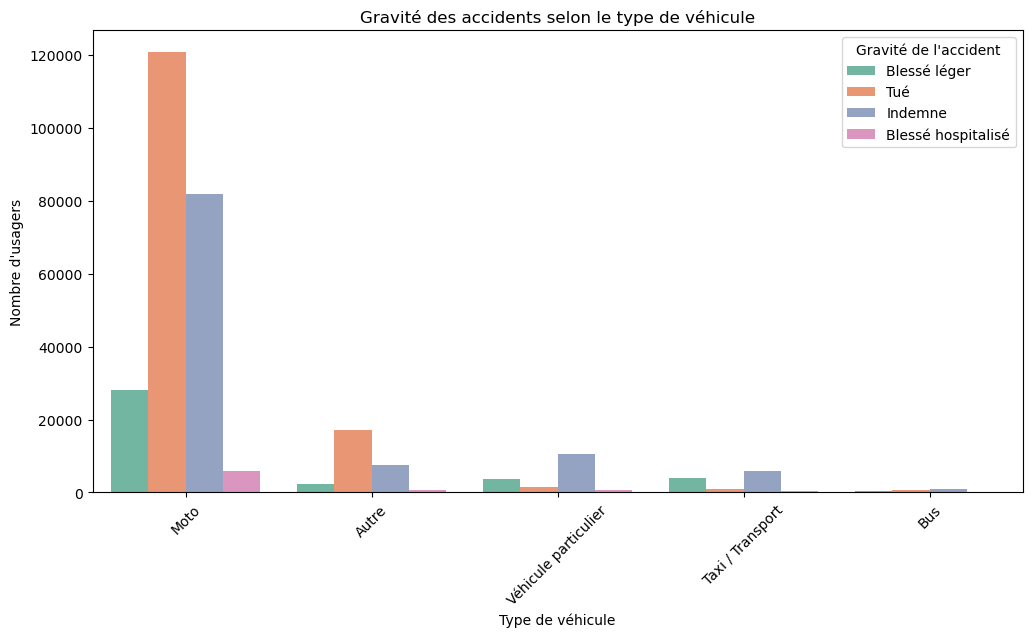

In [363]:
plt.figure(figsize=(12,6))
sns.countplot(
    data=df_merge_n, 
    x="catv_desc", 
    hue="grav_desc", 
    palette="Set2",
    order=df_merge_n["catv_desc"].value_counts().index
)
plt.title("Gravité des accidents selon le type de véhicule")
plt.xlabel("Type de véhicule")
plt.ylabel("Nombre d'usagers")
plt.legend(title="Gravité de l'accident")
plt.xticks(rotation=45)
plt.show()

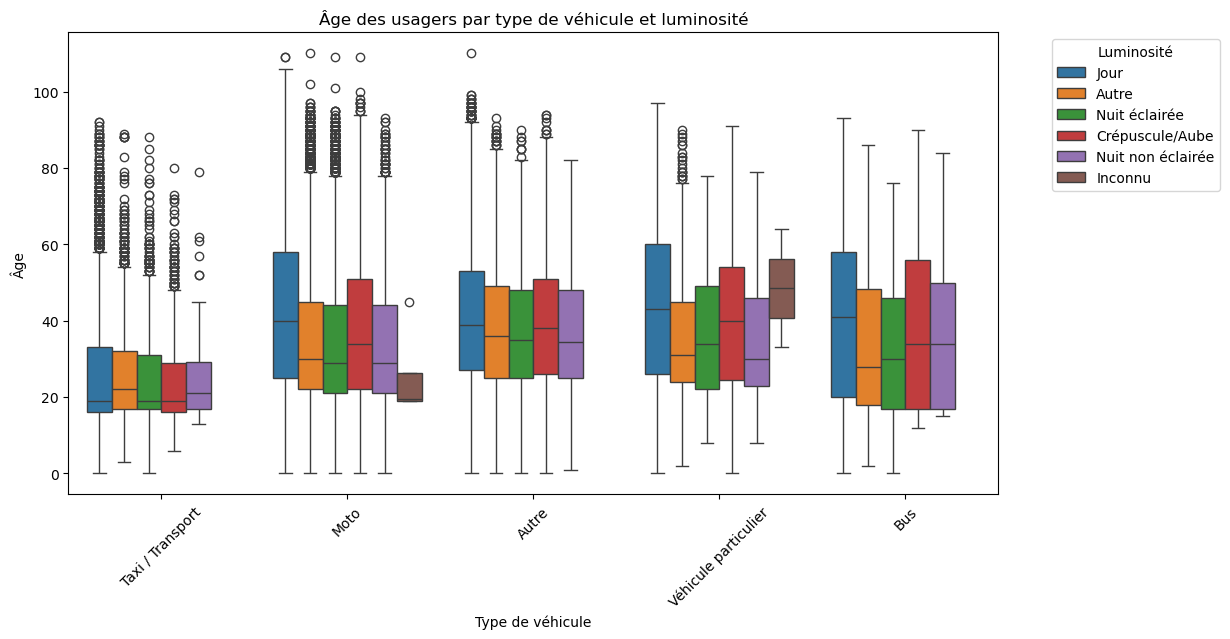

In [357]:
plt.figure(figsize=(12,6))
sns.boxplot(data=df_merge_n, x="catv_desc", y="age", hue="lum_desc")
plt.title("Âge des usagers par type de véhicule et luminosité")
plt.xlabel("Type de véhicule")
plt.ylabel("Âge")
plt.xticks(rotation=45)
plt.legend(title="Luminosité", bbox_to_anchor=(1.05,1), loc="upper left")
plt.show()

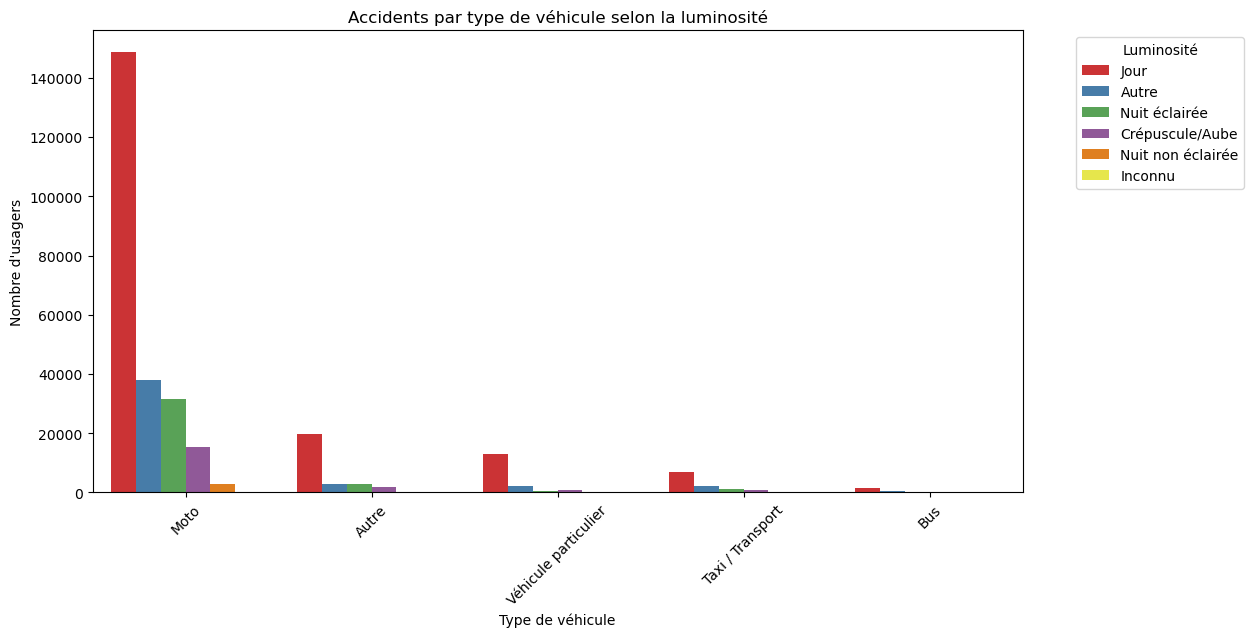

In [361]:
plt.figure(figsize=(12,6))
sns.countplot(data=df_merge_n, x="catv_desc", hue="lum_desc", palette="Set1", order=df_merge_n["catv_desc"].value_counts().index)
plt.title("Accidents par type de véhicule selon la luminosité")
plt.xlabel("Type de véhicule")
plt.ylabel("Nombre d'usagers")
plt.legend(title="Luminosité", bbox_to_anchor=(1.05,1), loc="upper left")
plt.xticks(rotation=45)
plt.show()

### Analyse des graphiques :

* Tendances générales
Le nombre total d'accidents reste stable autour de 57 000 accidents par an sur la période 2022-2024, avec un léger pic en juin-juillet et en septembre-octobre.
Corrélations principales identifiées :
Luminosité et gravité des accidents

La majorité des accidents (environ 36 000) se produisent en plein jour
Corrélation importante : Les accidents de nuit (éclairée ou non) sont moins fréquents mais potentiellement plus graves
Les accidents au crépuscule/aube représentent environ 4 000 cas

1. Type de route et fréquence

Route communale : environ 32 000 accidents (la plus dangereuse)
Route départementale : environ 27 000 accidents
Autoroute : environ 5 000 accidents (malgré le trafic élevé)
Corrélation : Les routes communales concentrent le plus d'accidents, probablement dû aux intersections, piétons et vitesses variables
Conditions météo

Temps normal : environ 42 000 accidents (75% du total)
Pluie légère : environ 7 000 accidents
Brouillard, pluie forte, neige : relativement faibles
Corrélation faible : La météo n'est pas le facteur principal - la majorité des accidents ont lieu par beau temps, suggérant que d'autres facteurs (trafic, comportement) sont plus déterminants

2. Type de véhicule

Motos : environ 240 000 usagers impliqués (le plus élevé)
Les motos montrent une surreprésentation alarmante
Corrélation forte : Les motards sont particulièrement vulnérables, surtout en plein jour
Genre des usagers

Hommes : environ 85 000 (68%)
Femmes : environ 39 000 (32%)
Corrélation : Les hommes sont impliqués dans 2 fois plus d'accidents

3. Âge et gravité

Distribution d'âge : pic entre 20-30 ans
Corrélation intéressante : L'âge médian des accidents graves (tués) est autour de 35-40 ans, tandis que les blessés légers ont un âge médian légèrement plus élevé (40-45 ans)
Les accidents mortels touchent une population légèrement plus jeune
Âge selon le type de véhicule

Motos : âge médian autour de 40 ans
Autres véhicules : distribution similaire autour de 35-50 ans
La luminosité influence différemment selon le véhicule - les motos sont particulièrement impliquées de jour



* Conclusions sur les causes principales :

Facteur humain dominant : La majorité des accidents ont lieu par temps normal et en plein jour, suggérant que le comportement (vitesse, attention, respect du code) est plus déterminant que les conditions externes
Vulnérabilité des deux-roues : Les motos sont disproportionnellement représentées
Routes à risque : Les routes communales et départementales sont plus dangereuses que les autoroutes, probablement en raison de leur complexité (intersections, traversées)
Genre et comportement : La surreprésentation masculine suggère des différences de comportement au volant
Jeunes conducteurs : Le pic d'accidents chez les 20-30 ans confirme l'inexpérience comme facteur de risque

### Analyse synthétique 

1️⃣ Tendances générales

Total d’accidents stable autour de 57 000/an (2022-2024).

Pics saisonniers : juin-juillet et septembre-octobre.

Les tendances peuvent être visualisées avec un graphique par mois et hue=année pour voir la progression.


2️⃣ Facteurs de luminosité

36 000 accidents en plein jour → majorité des cas.

Accidents nocturnes moins fréquents mais plus graves.

Crépuscule/aube : ~4 000 cas.

Analyse : le facteur lumière n’est pas le principal déclencheur, mais influence la gravité.
✅ Suggestion graphique : barplot de gravité par luminosité, ou stacked histogram par heure et luminosité.


3️⃣ Type de route

Route communale : ~32 000 accidents

Route départementale : ~27 000

Autoroute : ~5 000

Analyse : les routes communales sont plus accidentogènes, probablement en raison de trafic mixte, intersections, piétons.
✅ Graphique : countplot avec catr_desc et grav_desc.


4️⃣ Conditions météo

Temps normal : 75% des accidents (~42 000)

Pluie légère : ~7 000

Brouillard, forte pluie, neige : faibles

Analyse : la météo n’est pas un facteur déterminant.
✅ Graphique : countplot météo vs gravité.


5️⃣ Type de véhicule

Motos : ~240 000 usagers impliqués → surréprésentation alarmante

Autres véhicules : distribution plus uniforme

Luminosité joue un rôle spécifique pour les motos (plus exposées de jour)

Analyse : vulnérabilité des deux-roues.
✅ Graphiques :

* countplot par type de véhicule et sexe

* boxplot âge vs type de véhicule vs luminosité

* countplot gravité vs type de véhicule


6️⃣ Sexe des usagers

Hommes : 68%, Femmes : 32%
Analyse : comportement au volant et exposition plus élevée chez les hommes.


7️⃣ Âge et gravité

Pic entre 20-30 ans → jeunes conducteurs plus accidentogènes

Âge médian des tués : 35-40 ans

Âge médian des blessés légers : 40-45 ans

✅ Graphiques :

* histplot âge par gravité

* boxplot âge vs gravité

* boxplot âge vs type de véhicule



8️⃣ Conclusions principales

Facteur humain dominant : comportements au volant plus déterminants que météo ou luminosité.

Vulnérabilité des motos : proportion importante, surtout de jour.

Routes à risque : communales et départementales > autoroutes.

Sexe et comportement : surreprésentation masculine → possible comportement plus risqué.

Jeunes conducteurs : plus accidentogènes (20-30 ans).